# อิทธิพลของหุ้น Top 10 (market cap) ต่อ S&P 500 — Modelling Notebook

**คำถาม:** หุ้น 10 อันดับแรกตาม market cap (ซึ่งเปลี่ยนตัวได้ตลอดเวลา) อธิบายการเคลื่อนไหวรายวันของ S&P 500 ได้มากแค่ไหน และอันดับไหนสำคัญที่สุด

**ข้อมูล:** `modelling_table(new).csv` — 2,514 วันซื้อขาย (ม.ค. 2016 – ธ.ค. 2025)
- `close_1..close_10` = adj close ของหุ้นอันดับ 1–10 *ในวันนั้น* (เป็นช่องอันดับ ไม่ใช่หุ้นตัวเดิม)
- `target` = ระดับดัชนี S&P 500

**แนวทาง**
1. แปลงราคาเป็น **return รายวัน** และแก้ปัญหาช่องอันดับสลับกันด้วยการ *un-swap* (section 3) — ไม่ใช้ level เพราะ spurious (section 2)
2. โจทย์แบบ **same-day**: return ของอันดับ 1–10 วัน t → return ดัชนีวัน t (วัดอิทธิพล ไม่ใช่ทำนายอนาคต)
3. Split ตามเวลา: train 2,011 / test 503 และ expanding-window CV 4 fold × 365 วันใน train (section 4)
4. โมเดล: Linear + Ridge (baseline) → XGBoost → SVR → LSTM → AutoGluon — เลือก hyperparameter จาก CV เท่านั้น (random/grid search), วัด test ครั้งเดียว
5. วัดอิทธิพลด้วย R², sensitivity (coefficient), permutation importance + SHAP และดูการเปลี่ยนแปลงรายปี (section 11–13); สรุปผลและการตีความใน section 14; คำถามที่อาจถูกถามพร้อมคำตอบใน section 15
6. ทุกข้อสรุปมีการตรวจสอบประกบ: stationarity (ADF), same-day vs next-day, sensitivity ของพารามิเตอร์ un-swap, block bootstrap + Diebold–Mariano สำหรับความต่างระหว่างโมเดล, VIF

ผลลัพธ์ทั้งหมดถูกเก็บเป็น `dashboard_data.pkl` (ไม่สรุปเป็น csv) แล้วดูผ่าน dashboard: `streamlit run dashboard.py`

รันจากบนลงล่างตามลำดับ ใช้เวลา ~3 นาทีบน CPU (AutoGluon เพิ่มอีก ~10 นาที ถ้าเปิด) — package: numpy, pandas, scipy, scikit-learn, matplotlib, xgboost, shap, statsmodels, torch, (autogluon.tabular)

In [1]:
# ===== 0. Setup =====
AUTO_INSTALL = True          # pip install package ที่ยังไม่มีให้อัตโนมัติ (สะดวกบน Colab)
RUN_AUTOGLUON = True         # AutoGluon ติดตั้งหนัก (~2 GB): pip install "autogluon.tabular[all]"  — ตั้ง False ถ้าไม่ต้องการ
AG_TIME_LIMIT = 120          # วินาทีต่อการ fit AutoGluon 1 ครั้ง (fit ทั้งหมด 5 ครั้ง)
SEED = 42

import sys, subprocess, importlib, os, random, warnings, time
warnings.filterwarnings('ignore')
from pathlib import Path

def ensure(pip_name, import_name=None):
    try:
        importlib.import_module(import_name or pip_name)
    except ImportError:
        if not AUTO_INSTALL:
            raise
        print(f'installing {pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for pip_name, import_name in [('numpy', None), ('pandas', None), ('scipy', None), ('scikit-learn', 'sklearn'),
                              ('matplotlib', None), ('xgboost', None), ('shap', None), ('statsmodels', None)]:
    ensure(pip_name, import_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import ParameterGrid
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.3})

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()
print('python', sys.version.split()[0], '| numpy', np.__version__, '| pandas', pd.__version__)

python 3.11.9 | numpy 2.4.6 | pandas 2.3.3


## 1. โหลดข้อมูลและดูโครงสร้าง

จุดสำคัญของตารางนี้คือแต่ละคอลัมน์เป็น **ช่องอันดับ** — วันไหนอันดับ market cap สลับกัน ราคาก็กระโดดข้ามคอลัมน์ และช่อง 10 มีหุ้นเข้า/ออกบ่อย เซลล์ถัดไปพิสูจน์เรื่องนี้จากข้อมูลตรงๆ

In [2]:
# ===== 1. Load =====
CSV_PATH = 'modelling_table(new).csv'
if not Path(CSV_PATH).exists():
    try:
        from google.colab import files   # บน Colab: เปิดหน้าต่างให้อัปโหลดไฟล์
        CSV_PATH = list(files.upload())[0]
    except ImportError:
        raise FileNotFoundError(f'ไม่พบ {CSV_PATH} — วางไฟล์ไว้โฟลเดอร์เดียวกับ notebook')

raw = pd.read_csv(CSV_PATH)
raw['date'] = pd.to_datetime(raw['date'], format='%m/%d/%Y')
raw = raw.set_index('date').sort_index()
SLOT_COLS = [f'close_{k}' for k in range(1, 11)]
assert len(raw) == 2514, len(raw)
print(raw.shape, '|', raw.index.min().date(), '->', raw.index.max().date())
raw.describe().T[['min', 'max']].round(2)

(2514, 11) | 2016-01-04 -> 2025-12-31


,min,max
close_1,32.47,485.31
close_2,32.17,537.65
close_3,23.89,521.47
close_4,21.01,322.60
close_5,21.44,488.92
close_6,20.55,409.97
close_7,24.10,787.42
close_8,19.26,666.36
close_9,17.11,946.76
close_10,16.20,939.58


close_1 <-> close_2:   73 วัน
close_2 <-> close_3:   63 วัน
close_3 <-> close_4:   39 วัน
close_4 <-> close_5:   49 วัน
close_5 <-> close_6:    8 วัน
close_6 <-> close_7:   54 วัน
close_7 <-> close_8:   30 วัน
close_8 <-> close_9:   98 วัน
close_9 <-> close_10:  115 วัน


date,2016-01-12,2016-01-13,2016-01-14,2016-01-15,2016-01-19,2016-01-20,2016-01-21
close_5,30.89,29.09,50.05,49.08,48.33,28.59,28.75
close_6,47.57,47.86,29.65,28.51,28.72,46.29,46.88


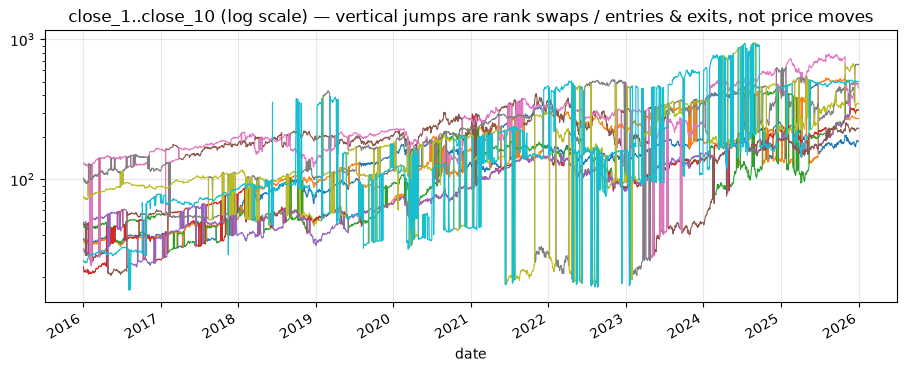

In [3]:
# หลักฐานว่าคอลัมน์เป็นช่องอันดับ: ค่าสลับกันระหว่างคอลัมน์ติดกันบ่อยมาก
P = raw[SLOT_COLS].to_numpy()
prev, cur = P[:-1], P[1:]
for k in range(9):
    a_to_b = np.abs(cur[:, k] - prev[:, k + 1]) / prev[:, k + 1] < 0.10
    b_to_a = np.abs(cur[:, k + 1] - prev[:, k]) / prev[:, k] < 0.10
    jump = np.abs(cur[:, k] - prev[:, k]) / prev[:, k] > 0.20
    print(f'close_{k+1} <-> close_{k+2}: {(a_to_b & b_to_a & jump).sum():4d} วัน')
display(raw.loc['2016-01-12':'2016-01-21', ['close_5', 'close_6']].round(2).T)   # ตัวอย่าง: สลับไปแล้วสลับกลับ

fig, ax = plt.subplots(figsize=(11, 4))
raw[SLOT_COLS].plot(ax=ax, lw=0.8, legend=False, logy=True)
ax.set_title('close_1..close_10 (log scale) — vertical jumps are rank swaps / entries & exits, not price moves')
plt.show()

## 2. ทำไมไม่ใช้ระดับราคา (level)

ถ้าเอาราคา top 10 (normalize แล้ว) ไปทำนาย *ระดับ* ดัชนีตรงๆ จะได้ train R² ≈ 0.99 แต่ไม่มีความหมาย เพราะ
1. ทุก series ขึ้นพร้อมกันตลอด 10 ปี — feature ที่เป็นแค่ *ลำดับวัน* ก็ได้ R² ใกล้เคียงกัน (placebo test ด้านล่าง)
2. Tree model (XGBoost) ทำนายเกินช่วงค่าที่เคยเห็นตอน train ไม่ได้ — ช่วง test (2024–25) ดัชนีอยู่ 4,700–6,900 สูงกว่า train ทั้งหมด
3. Residual มี autocorrelation สูงมาก (Durbin-Watson ≈ 0) = spurious regression

เซลล์นี้เก็บไว้เป็นหลักฐานประกอบรายงาน ส่วนการวิเคราะห์จริงใช้ return ตั้งแต่ section 3 เป็นต้นไป

placebo (time index only)   train R2 = 0.881
Linear   level model           train R2 = 0.981   test R2 = 0.622
XGBoost  level model           train R2 = 1.000   test R2 = -4.136


ADF p-value   level = 0.984 (non-stationary -> regression บน level เป็น spurious)   |   daily return = 3.4e-29 (stationary)


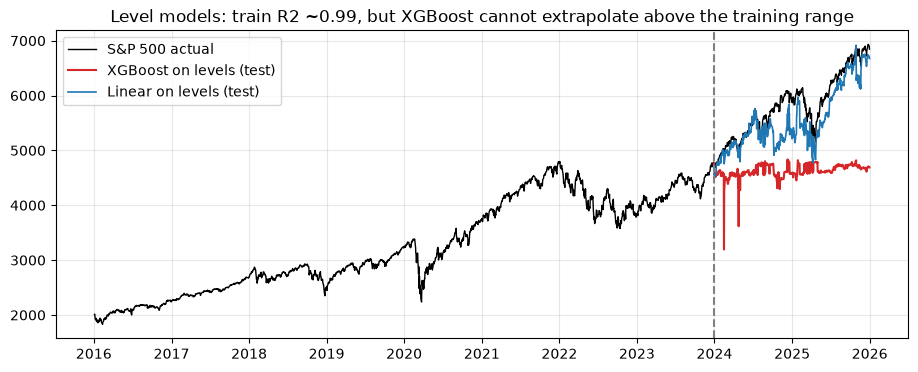

In [4]:
# ===== 2. Level model = spurious =====
SPLIT_AT = 2011                       # train 2,011 แถวแรก / test 503 แถวหลัง (ตามโน้ต)
y_lvl = raw['target'].to_numpy()
tr, te = slice(0, SPLIT_AT), slice(SPLIT_AT, None)

# (a) placebo: feature เดียวคือลำดับวัน 1,2,3,...
t_idx = np.arange(len(raw)).reshape(-1, 1)
lr = LinearRegression().fit(t_idx[tr], y_lvl[tr])
print(f'placebo (time index only)   train R2 = {r2_score(y_lvl[tr], lr.predict(t_idx[tr])):.3f}')

# (b) ราคา top10 normalize (fit scaler บน train เท่านั้น) -> ระดับดัชนี
sc = MinMaxScaler().fit(raw[SLOT_COLS].iloc[tr])
X_lvl = sc.transform(raw[SLOT_COLS])
level_models = {'Linear': LinearRegression(),
                'XGBoost': XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, random_state=SEED)}
level_pred = {}
for name, m in level_models.items():
    m.fit(X_lvl[tr], y_lvl[tr])
    level_pred[name] = m.predict(X_lvl)
    print(f'{name:8s} level model           train R2 = {r2_score(y_lvl[tr], level_pred[name][tr]):.3f}   '
          f'test R2 = {r2_score(y_lvl[te], level_pred[name][te]):.3f}')

# (c) stationarity: ADF test — level มี unit root (p สูง) แต่ return รายวัน stationary (p ~ 0)
from statsmodels.tsa.stattools import adfuller
adf_level_p = float(adfuller(y_lvl, autolag='AIC')[1])
adf_return_p = float(adfuller(raw['target'].pct_change().dropna().to_numpy(), autolag='AIC')[1])
print(f'ADF p-value   level = {adf_level_p:.3f} (non-stationary -> regression บน level เป็น spurious)   |   daily return = {adf_return_p:.1e} (stationary)')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(raw.index, y_lvl, color='k', lw=1, label='S&P 500 actual')
ax.plot(raw.index[te], level_pred['XGBoost'][te], color='C3', lw=1.5, label='XGBoost on levels (test)')
ax.plot(raw.index[te], level_pred['Linear'][te], color='C0', lw=1.2, label='Linear on levels (test)')
ax.axvline(raw.index[SPLIT_AT], color='gray', ls='--')
ax.set_title('Level models: train R2 ~0.99, but XGBoost cannot extrapolate above the training range')
ax.legend()
plt.show()

## 3. Un-swap → return รายวัน

วันที่อันดับสลับกัน ชุดราคา 10 ค่าเหมือนเดิมแค่เปลี่ยนตำแหน่ง จึงต้องจับคู่ค่าวัน t กับค่าวัน t−1 ให้เป็น *บริษัทเดิม* ก่อนคำนวณ return — `r_k(t)` = return วันนี้ของบริษัทที่อยู่อันดับ k ในวัน t

การจับคู่ด้วย "ราคาที่ใกล้ที่สุด" แบบตรงไปตรงมาไม่พอ เพราะ (1) มีคู่หุ้นราคาใกล้กันมากอยู่ตลอด (GOOGL/GOOG ต่างกัน <1–3%) ทำให้จับสลับตัวกันบ่อย และ (2) วันตลาดผันผวน ±10% ทุกตัวขยับพร้อมกัน วิธีที่ใช้:

1. **Optimal assignment (Hungarian)** ต่อวัน โดย cost = |log return − market proxy| (capped ที่ 35%) **+ penalty 1% ต่อการเลื่อน 1 อันดับ** — อันดับ market cap เปลี่ยนช้า ดังนั้นเมื่อหลักฐานจากราคาก้ำกึ่ง ให้เชื่อว่าอยู่อันดับเดิม
2. **Market proxy** = median ของ return 10 ช่องในวันนั้น (ไม่ใช้ `target` → ไม่มี leakage) ใช้ทั้งตอนจับคู่และตอนตัดสินว่าการขยับใหญ่เป็น *idiosyncratic* หรือขยับตามตลาด
3. **หุ้นเข้า/ออก top 10** (ช่องนั้นไม่มี return จริง → NaN):
   - |log return| > 35% → เปลี่ยนตัวแน่นอน
   - อันดับ 1–8: นอกจากนั้นถือเป็นการขยับจริงทั้งหมด (หุ้นเข้า/ออกที่อันดับสูงแทบไม่เกิด แต่การขยับจริง 10–25% เกิดในวันงบ เช่น META, NVDA, TSLA)
   - อันดับ 9–10 (boundary ที่หุ้นสลับเข้าออกจริง): idiosyncratic move > 20% → เปลี่ยนตัว; 8–20% → ต้องมีหลักฐาน คือ *ราคาหุ้นที่เข้ามาตรงกับหุ้นที่เพิ่งออกไปใน 30 วัน* หรือ *หุ้นที่ออกไปกลับมาภายใน 20 วันและตัวที่เข้ามาหายไป* (tolerance ขยายตาม √วันที่หายไป และปรับด้วย market proxy)
4. ช่อง NaN เติมด้วยค่าเฉลี่ยของช่องอื่นในวันเดียวกัน (proxy ว่าหุ้นใหม่ขยับตามกลุ่ม)

ทุก return อยู่ในหน่วย **%** (coefficient ไม่เปลี่ยน, RMSE อ่านง่าย, SVR ตั้ง epsilon ได้ตรงไปตรงมา) — เซลล์ถัดไปพิมพ์ diagnostics (จำนวนวันสลับ, รายการหุ้นเข้า/ออกพร้อมเหตุผล, การขยับใหญ่ที่เก็บไว้) และเซลล์ตรวจสอบเทียบผลกับการไม่ un-swap

In [5]:
# ===== 3. Un-swap -> daily returns =====
from scipy.optimize import linear_sum_assignment

RET_COLS = [f'r_{k}' for k in range(1, 11)]
TARGET = 'r_target'

def unswap_returns(prices, lam=0.01, cap=0.35, th_idio=0.08, th_big=0.20, boundary=8, dormant_days=30, look_days=20):
    '''
    คืน (returns, diag, market_proxy)
      returns : DataFrame r_1..r_10 (simple return, NaN = หุ้นเข้า/ออก หรือแถวแรก) + swapped + n_unmatched
      diag    : รายการทุก event ที่ idiosyncratic move > th_idio พร้อม status (real/exit) และเหตุผล
    '''
    LP = np.log(prices[SLOT_COLS].to_numpy(dtype=float))
    T, K = LP.shape
    pen = lam * np.abs(np.arange(K)[:, None] - np.arange(K)[None, :])      # penalty ต่อการเลื่อนอันดับ

    def assign(t, shift):
        C = np.minimum(np.abs(LP[t][:, None] - LP[t - 1][None, :] - shift), cap) + pen
        ri, cj = linear_sum_assignment(C)
        s = np.empty(K, int); s[ri] = cj
        return s

    # pass 1: จับคู่แบบดิบเพื่อประมาณ market proxy -> pass 2: จับคู่ใหม่ด้วย cost ที่หัก market proxy
    sigma = np.zeros((T, K), int); rho = np.full((T, K), np.nan); med = np.zeros(T)
    for t in range(1, T):
        d1 = LP[t] - LP[t - 1][assign(t, 0.0)]
        m1 = np.median(d1[np.abs(d1) < cap]) if (np.abs(d1) < cap).any() else 0.0
        sigma[t] = assign(t, m1)
        rho[t] = LP[t] - LP[t - 1][sigma[t]]
        ok = np.abs(rho[t] - m1) < cap
        med[t] = np.median(rho[t][ok]) if ok.any() else m1
    M = np.cumsum(med)                                                      # market proxy สะสม (log)
    tol = lambda k: 0.02 + 0.02 * np.sqrt(max(k, 1))                        # tolerance ขยายตามจำนวนวันที่หายไป

    # pass 3: ตัดสินว่าแต่ละคู่เป็นการขยับจริง หรือหุ้นเข้า/ออก
    R = np.full((T, K), np.nan); src = np.full((T, K), -1, int); rows = []
    dormant = []                                                            # [log price ตอนออก, วันสุดท้ายที่อยู่, อันดับ]
    for t in range(1, T):
        exits = []
        for i in range(K):
            j = sigma[t, i]; a = abs(rho[t, i]); a_ex = abs(rho[t, i] - med[t])
            kind, why = 'real', ''
            at_boundary = i >= boundary or j >= boundary
            if a > cap:
                kind, why = 'exit', f'|log return| {a:.0%} > {cap:.0%}'
            elif at_boundary and a_ex > th_big:
                kind, why = 'exit', f'idiosyncratic jump {a_ex:.0%} > {th_big:.0%} at rank 9-10'
            elif at_boundary and a_ex > th_idio:
                hit = next((d for d in dormant if abs(LP[t, i] - (d[0] + M[t] - M[d[1]])) < tol(t - d[1])), None)
                if hit is not None:                                         # หลักฐาน 1: ตัวที่เข้ามา = หุ้นที่เพิ่งออกไป
                    kind, why = 'exit', f'entrant = company that left {t - hit[1]}d ago'
                    dormant.remove(hit)
                else:                                                       # หลักฐาน 2: หุ้นที่ออกกลับมาเร็วๆ นี้ และตัวที่เข้ามาหายไป
                    for k in range(1, look_days + 1):
                        if t + k >= T:
                            break
                        back = np.abs(LP[t + k] - (LP[t - 1, j] + M[t + k] - M[t - 1])) < tol(k + 1)
                        back[:boundary] = False
                        new_app = np.abs((LP[t + k] - LP[t + k - 1]) - med[t + k]) > th_idio
                        entrant_gone = not (np.abs(LP[t + k] - (LP[t, i] + M[t + k] - M[t])) < tol(k)).any()
                        if (back & new_app).any() and entrant_gone:
                            kind, why = 'exit', f'exiting company returns after {k}d'
                            break
            if kind == 'exit':
                exits.append(j)
            else:
                R[t, i] = rho[t, i]; src[t, i] = j
            if a_ex > th_idio or a > cap:
                rows.append({'date': prices.index[t], 'slot': i + 1, 'prev_slot': j + 1, 'prev_value': np.exp(LP[t - 1, j]),
                             'new_value': np.exp(LP[t, i]), 'pct_move': 100 * np.expm1(rho[t, i]),
                             'top10_median_%': 100 * np.expm1(med[t]), 'status': kind, 'reason': why})
        for j in exits:
            dormant.append([LP[t - 1, j], t - 1, j])
        dormant = [d for d in dormant if t - d[1] <= dormant_days]

    out = pd.DataFrame(np.expm1(R), index=prices.index, columns=RET_COLS)
    matched = src >= 0
    out['swapped'] = ((src != np.arange(K)[None, :]) & matched).any(axis=1)
    out['n_unmatched'] = (~matched).sum(axis=1)
    out.iloc[0, out.columns.get_loc('n_unmatched')] = 0                    # แถวแรกไม่มีวันก่อนหน้า
    diag = pd.DataFrame(rows, columns=['date', 'slot', 'prev_slot', 'prev_value', 'new_value', 'pct_move',
                                       'top10_median_%', 'status', 'reason']).set_index('date')
    return out, diag, pd.Series(np.expm1(med) * 100, index=prices.index, name='top10_median_%')

rets, diag, mkt_proxy = unswap_returns(raw)
exit_by_rank = rets[RET_COLS].iloc[1:].isna().sum()
row_mean = rets[RET_COLS].mean(axis=1)
for c in RET_COLS:                                   # วันหุ้นเข้า/ออก: เติมด้วยค่าเฉลี่ยของช่องอื่นวันนั้น
    rets[c] = rets[c].fillna(row_mean)

df = rets.copy()
df[TARGET] = raw['target'].pct_change()
df[RET_COLS + [TARGET]] *= 100                      # หน่วย % ทั้งหมด
df['target_level'] = raw['target']

print(f'days with a rank swap: {int(df.swapped.sum())} / {len(df) - 1}')
print(f'entry/exit slots: {int(df.n_unmatched.sum())} in {int((df.n_unmatched > 0).sum())} days  ->  by rank: '
      + str({k + 1: int(v) for k, v in enumerate(exit_by_rank)}))
print('event classification:', diag.status.value_counts().to_dict())
print()
print('entry/exit decided by evidence rules (not the 35% threshold):')
display(diag[(diag.status == 'exit') & ~diag.reason.str.startswith('|log')].drop(columns='status').round(2))
print('large idiosyncratic moves KEPT as real (>8% vs top-10 median):')
display(diag[diag.status == 'real'].drop(columns=['status', 'reason']).round(2))
df[RET_COLS + [TARGET]].describe().T[['mean', 'std', 'min', 'max']].round(2)

days with a rank swap: 698 / 2513
entry/exit slots: 206 in 206 days  ->  by rank: {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 8, 10: 198}
event classification: {'exit': 206, 'real': 84}

entry/exit decided by evidence rules (not the 35% threshold):


,slot,prev_slot,prev_value,new_value,pct_move,top10_median_%,reason
date,,,,,,,
2016-11-14,10,10,69.94,61.58,-11.96,-2.39,entrant = company that left 26d ago
2016-11-15,10,10,61.58,71.47,16.05,1.91,entrant = company that left 2d ago
2016-12-06,10,10,75.02,64.82,-13.60,-0.01,entrant = company that left 28d ago
2016-12-07,10,10,64.82,75.81,16.96,1.29,entrant = company that left 2d ago
2016-12-08,10,10,75.81,65.93,-13.04,0.09,entrant = company that left 17d ago
2016-12-12,10,10,66.21,77.61,17.21,0.16,entrant = company that left 3d ago
2017-01-03,10,10,77.97,67.56,-13.35,0.62,entrant = company that left 18d ago
2017-01-04,10,10,67.56,78.05,15.53,0.03,entrant = company that left 2d ago
2017-01-09,10,10,77.40,67.12,-13.29,0.02,entrant = company that left 19d ago


large idiosyncratic moves KEPT as real (>8% vs top-10 median):


,slot,prev_slot,prev_value,new_value,pct_move,top10_median_%
date,,,,,,
2016-01-28,7,9,93.63,108.16,15.52,1.95
2016-01-29,6,5,31.77,29.35,-7.61,2.04
2016-04-28,8,8,107.94,115.71,7.20,-1.17
2016-04-29,5,6,30.10,32.98,9.57,0.11
2017-10-27,5,5,48.62,55.05,13.22,3.92
...,...,...,...,...,...,...
2025-09-05,8,8,303.87,332.45,9.41,0.23
2025-09-10,8,8,334.22,366.88,9.77,-0.18
2025-10-30,9,7,749.72,664.74,-11.33,-2.23


,mean,std,min,max
r_1,0.15,1.87,-14.74,15.33
r_2,0.11,1.75,-9.88,11.98
r_3,0.12,2.11,-16.97,18.72
r_4,0.13,1.83,-11.10,11.98
r_5,0.08,1.96,-14.05,13.54
r_6,0.14,2.50,-18.96,24.37
r_7,0.11,2.19,-14.25,20.32
r_8,0.13,2.12,-21.06,21.92
r_9,0.12,2.10,-14.26,22.69
r_10,-0.01,1.76,-15.43,18.66


naive same-slot return   linear R2  train 0.249   test -1.888
un-swapped return        linear R2  train 0.831   test 0.707
near-identical price pairs: 1994 pair-days, corr of their returns = 0.976 (ควรใกล้ 1)
next-day (X_t-1 -> y_t) linear R2  train 0.028   test -0.031   <- เทียบ same-day 0.83 / 0.71
corr(equal-weight top-10 return, S&P return) = 0.899   |   corr(top-10 median proxy, S&P) = 0.904


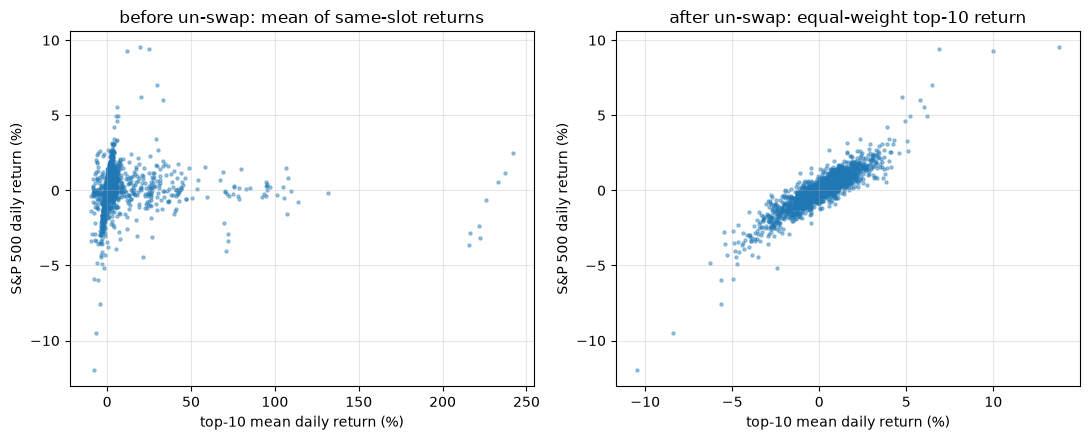

In [6]:
# ===== ตรวจสอบคุณภาพการ un-swap =====
y_chk = df[TARGET].to_numpy()
tr_i, te_i = np.arange(1, 2011), np.arange(2011, len(df))      # split เดียวกับ section 4 (train 2016-2023 / test 2024-2025)

# (1) เทียบกับการไม่ un-swap (ใช้ return ของช่องเดิมตรงๆ): linear regression เดียวกัน
naive = (raw[SLOT_COLS] / raw[SLOT_COLS].shift(1) - 1).to_numpy() * 100
for name, XX in [('naive same-slot return', naive), ('un-swapped return', df[RET_COLS].to_numpy())]:
    lr_chk = LinearRegression().fit(XX[tr_i], y_chk[tr_i])
    print(f'{name:24s} linear R2  train {lr_chk.score(XX[tr_i], y_chk[tr_i]):.3f}   test {lr_chk.score(XX[te_i], y_chk[te_i]):.3f}')

# (2) คู่หุ้นที่ราคาใกล้กันมาก (<1% สองวันติด เช่น GOOGL/GOOG) return ควรเกือบเท่ากัน -> ถ้าจับคู่ผิด correlation จะต่ำ
P_ = raw[SLOT_COLS].to_numpy(); R_ = df[RET_COLS].to_numpy(); gap = np.abs(np.log(P_[:, :, None] / P_[:, None, :]))
close_pair = (gap[1:] < 0.01) & (gap[:-1] < 0.01)
ii, jj = np.triu_indices(10, k=1)
mask = close_pair[:, ii, jj]
a_, b_ = R_[1:][:, ii][mask], R_[1:][:, jj][mask]
print(f'near-identical price pairs: {mask.sum()} pair-days, corr of their returns = {np.corrcoef(a_, b_)[0, 1]:.3f} (ควรใกล้ 1)')

# (3) same-day vs next-day: ถ้าใช้ return ของ top 10 *เมื่อวาน* ทำนายดัชนี *วันนี้* R² ต้อง ~0 (ตลาดมีประสิทธิภาพ)
#     -> ยืนยันว่าสิ่งที่วัดในงานนี้คือความสัมพันธ์ same-day (อิทธิพล) ไม่ใช่การทำนายอนาคต และไม่มี look-ahead ซ่อนอยู่
X_lag = np.vstack([np.full((1, 10), np.nan), df[RET_COLS].to_numpy()[:-1]])      # feature ของวันก่อนหน้า
tr_l = np.arange(2, 2011)
lr_lag = LinearRegression().fit(X_lag[tr_l], y_chk[tr_l])
nextday_r2 = {'train': float(lr_lag.score(X_lag[tr_l], y_chk[tr_l])), 'test': float(lr_lag.score(X_lag[te_i], y_chk[te_i]))}
print(f"next-day (X_t-1 -> y_t) linear R2  train {nextday_r2['train']:.3f}   test {nextday_r2['test']:.3f}   <- เทียบ same-day 0.83 / 0.71")

# (4) ความสัมพันธ์ same-day
ew = df[RET_COLS].mean(axis=1)
print(f'corr(equal-weight top-10 return, S&P return) = {ew.corr(df[TARGET]):.3f}   |   corr(top-10 median proxy, S&P) = {mkt_proxy.corr(df[TARGET]):.3f}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(naive.mean(axis=1), y_chk, s=5, alpha=0.4); axes[0].set_title('before un-swap: mean of same-slot returns')
axes[1].scatter(ew, y_chk, s=5, alpha=0.4); axes[1].set_title('after un-swap: equal-weight top-10 return')
for ax in axes:
    ax.set_xlabel('top-10 mean daily return (%)'); ax.set_ylabel('S&P 500 daily return (%)')
plt.tight_layout(); plt.show()

In [7]:
# ===== 3b. Sensitivity: พารามิเตอร์ของ un-swap และวิธี impute เปลี่ยนผลไหม? =====
# ทุกแถวใช้ pipeline เดียวกัน: un-swap -> impute -> Linear regression (train 2016-2023) -> R2 บน test 2024-25
def _twin_corr(R_):
    a2, b2 = R_[1:][:, ii][mask], R_[1:][:, jj][mask]
    ok2 = ~np.isnan(a2) & ~np.isnan(b2)
    return float(np.corrcoef(a2[ok2], b2[ok2])[0, 1])

def sensitivity_row(label, impute='cross_mean', **kw):
    r_, _, _ = unswap_returns(raw, **kw)
    r_ = r_[RET_COLS]
    n_exit = int(r_.iloc[1:].isna().sum().sum())
    if impute == 'cross_mean':
        r_ = r_.apply(lambda col: col.fillna(r_.mean(axis=1)))
    elif impute == 'zero':
        r_ = r_.fillna(0.0)
    Xs = r_.to_numpy() * 100
    keep_tr, keep_te = tr_i, te_i
    if impute == 'drop':                                            # ตัดวันที่มีหุ้นเข้า/ออกทิ้งทั้ง train และ test
        ok_rows = ~np.isnan(Xs).any(axis=1)
        keep_tr, keep_te = tr_i[ok_rows[tr_i]], te_i[ok_rows[te_i]]
    lr_s = LinearRegression().fit(Xs[keep_tr], y_chk[keep_tr])
    return {'setting': label, 'entry/exit slots': n_exit, 'twin corr': _twin_corr(r_.to_numpy()),
            'corr(EW,S&P)': float(np.corrcoef(np.nanmean(Xs[1:], axis=1), y_chk[1:])[0, 1]) if impute != 'drop' else np.nan,
            'linear R2 train': float(lr_s.score(Xs[keep_tr], y_chk[keep_tr])), 'linear R2 test': float(lr_s.score(Xs[keep_te], y_chk[keep_te]))}

settings = [
    ('baseline (lam .01, cap .35, big .20, idio .08, cross-mean)', {}),
    ('no rank penalty (lam 0)', {'lam': 0.0}),
    ('lam 0.005', {'lam': 0.005}), ('lam 0.02', {'lam': 0.02}),
    ('cap 0.30', {'cap': 0.30}), ('cap 0.50', {'cap': 0.50}),
    ('boundary jump rule 15%', {'th_big': 0.15}), ('boundary jump rule 25%', {'th_big': 0.25}), ('boundary jump rule off', {'th_big': 9.0}),
    ('idiosyncratic threshold 5%', {'th_idio': 0.05}), ('idiosyncratic threshold 12%', {'th_idio': 0.12}),
    ('boundary = ranks 8-10', {'boundary': 7}), ('boundary = rank 10 only', {'boundary': 9}),
    ('impute = 0 instead of cross-mean', {'impute': 'zero'}), ('drop entry/exit days instead of impute', {'impute': 'drop'}),
]
sensitivity = pd.DataFrame([sensitivity_row(lab, **kw) for lab, kw in settings]).set_index('setting')
display(sensitivity.round(3))
print('อ่านผล: corr(EW,S&P) และ R2 train แทบไม่เปลี่ยนในทุก setting -> ข้อสรุประดับรวมไม่ขึ้นกับพารามิเตอร์')
print('  - rank penalty (lam) จำเป็นสำหรับความถูกต้องรายช่อง: เอาออกแล้ว twin corr ตกจาก 0.976 เหลือ ~0.92 แม้ R2 รวมไม่เปลี่ยน')
print('  - กฎ boundary jump >20% มีผลต่อ R2 test (ปิดกฎ -> ~0.63) เพราะ event ปลอมจากการสลับ TSLA/AVGO ที่อันดับ 10 เกือบทั้งหมดอยู่ในปี 2024 (ช่วง test)')
print('    เกณฑ์ 20% ตั้งจากการตรวจ event เหล่านั้นกับราคาจริงของหุ้น (data cleaning) ไม่ใช่จากการจูนให้ R2 test สูง; เพื่อความโปร่งใสจึงแสดงผลเมื่อใช้ 15%/25%/ปิดกฎ ไว้ตรงนี้')

,entry/exit slots,twin corr,"corr(EW,S&P)",linear R2 train,linear R2 test
setting,,,,,
"baseline (lam .01, cap .35, big .20, idio .08, cross-mean)",206,0.976,0.899,0.831,0.707
no rank penalty (lam 0),205,0.924,0.899,0.826,0.719
lam 0.005,207,0.969,0.899,0.831,0.705
lam 0.02,206,0.976,0.899,0.831,0.708
cap 0.30,206,0.976,0.899,0.831,0.707
cap 0.50,206,0.976,0.899,0.830,0.712
boundary jump rule 15%,207,0.976,0.900,0.831,0.711
boundary jump rule 25%,204,0.976,0.898,0.831,0.661
boundary jump rule off,203,0.976,0.898,0.831,0.626


อ่านผล: corr(EW,S&P) และ R2 train แทบไม่เปลี่ยนในทุก setting -> ข้อสรุประดับรวมไม่ขึ้นกับพารามิเตอร์
  - rank penalty (lam) จำเป็นสำหรับความถูกต้องรายช่อง: เอาออกแล้ว twin corr ตกจาก 0.976 เหลือ ~0.92 แม้ R2 รวมไม่เปลี่ยน
  - กฎ boundary jump >20% มีผลต่อ R2 test (ปิดกฎ -> ~0.63) เพราะ event ปลอมจากการสลับ TSLA/AVGO ที่อันดับ 10 เกือบทั้งหมดอยู่ในปี 2024 (ช่วง test)
    เกณฑ์ 20% ตั้งจากการตรวจ event เหล่านั้นกับราคาจริงของหุ้น (data cleaning) ไม่ใช่จากการจูนให้ R2 test สูง; เพื่อความโปร่งใสจึงแสดงผลเมื่อใช้ 15%/25%/ปิดกฎ ไว้ตรงนี้


## 4. Split (ตามโน้ต)

| | Train | Val / Test |
|---|---|---|
| fold1 | แถว 1–551 | 552–916 |
| fold2 | 1–916 | 917–1,281 (มี COVID crash) |
| fold3 | 1–1,281 | 1,282–1,646 (มี bear market 2022) |
| fold4 | 1–1,646 | 1,647–2,011 |
| test | 1–2,011 | 2,012–2,514 (ธ.ค. 2023 – ธ.ค. 2025) |

เลขแถวในโน้ตเป็น 1-based; ในโค้ดเป็น 0-based ของ DataFrame แถว 0 ไม่มี return (ไม่มีวันก่อนหน้า) จึงถูกตัดออกจาก train อัตโนมัติ

In [8]:
# ===== 4. Split =====
FOLD_BOUNDS = [(551, 916), (916, 1281), (1281, 1646), (1646, 2011)]
FOLDS = [{'name': f'fold{k}', 'train': np.arange(0, a), 'val': np.arange(a, b)} for k, (a, b) in enumerate(FOLD_BOUNDS, 1)]
TEST = {'name': 'test', 'train': np.arange(0, 2011), 'val': np.arange(2011, len(df))}

X_all = df[RET_COLS]                 # feature ทุกแถว (DataFrame)
y_all = df[TARGET].to_numpy()        # แถว 0 = NaN

def valid(idx):
    return idx[~np.isnan(y_all[idx])]

split_tbl = []
for s in FOLDS + [TEST]:
    tr_d, va_d = df.index[s['train']], df.index[s['val']]
    split_tbl.append({'split': s['name'], 'train_rows': len(valid(s['train'])), 'train': f'{tr_d[0].date()} -> {tr_d[-1].date()}',
                      'val_rows': len(s['val']), 'val/test': f'{va_d[0].date()} -> {va_d[-1].date()}',
                      'val_std_%': round(float(df[TARGET].iloc[s['val']].std()), 2)})
pd.DataFrame(split_tbl)

,split,train_rows,train,val_rows,val/test,val_std_%
0,fold1,550,2016-01-04 -> 2018-03-12,365,2018-03-13 -> 2019-08-22,0.96
1,fold2,915,2016-01-04 -> 2019-08-22,365,2019-08-23 -> 2021-02-03,1.85
2,fold3,1280,2016-01-04 -> 2021-02-03,365,2021-02-04 -> 2022-07-18,1.14
3,fold4,1645,2016-01-04 -> 2022-07-18,365,2022-07-19 -> 2023-12-28,1.09
4,test,2010,2016-01-04 -> 2023-12-28,503,2023-12-29 -> 2025-12-31,1.00


## 5. กติกาการประเมิน (ใช้เหมือนกันทุกโมเดล)

- **Metric:** R² คำนวณบน return รายวัน; **MAE, MSE, RMSE (หน่วยจุดดัชนี) และ MAPE (%) คำนวณบนระดับดัชนี** โดยแปลง return ที่ทำนายเป็นระดับ = ระดับเมื่อวาน × (1 + return ที่ทำนาย) แล้วเทียบระดับจริง — วัดบน val ของแต่ละ fold และบน test; MAPE ไม่คำนวณบน return โดยตรง เพราะสูตรหารด้วย |ค่าจริง| ซึ่ง return รายวันใกล้ 0 บ่อยมาก จะได้ตัวเลขหลายร้อย % ที่ไม่สื่ออะไร
- **Scaler** fit บน train ของ fold นั้นเท่านั้น (SVR / LSTM)
- **เลือก hyperparameter** จากค่าเฉลี่ย R² ของ 4 val fold เท่านั้น → fit ใหม่บน train ทั้งหมด (2,011 แถว) → วัด test **ครั้งเดียว** ไม่กลับไปจูนหลังเห็น test
- **LSTM / AutoGluon** ต้องมีชุดข้อมูลไว้ทำ early stopping / model selection ภายใน → ใช้ส่วนท้ายของ train (เรียงตามเวลา) ไม่ใช่ val fold และไม่สุ่มแบ่ง
- ทุกโมเดลผ่าน wrapper เดียวกัน `fit(X_all, y_all, idx)` / `predict_rows(X_all, idx)` เพื่อให้ split ตรงกันเป๊ะ และใช้ permutation importance ร่วมกันได้

In [9]:
# ===== 5. Framework =====
results, preds, final_models = [], {}, {}

METRIC_COLS = ['R2', 'MAE', 'MSE', 'RMSE', 'MAPE_%']

def metrics(y, p, idx=None):
    '''y, p = return รายวันจริง/ทำนาย (หน่วย %)
    R2      คำนวณบน return (สัดส่วนความแปรปรวนของ return รายวันที่อธิบายได้)
    MAE, MSE, RMSE, MAPE คำนวณบน *ระดับดัชนี* (หน่วย: จุดดัชนี / จุด² / จุด / %):
        ระดับที่ทำนาย = ระดับเมื่อวาน × (1 + return ที่ทำนาย/100)  แล้วเทียบกับระดับจริงของวันนั้น
      - MAE  = พลาดเฉลี่ยกี่จุด, RMSE = √MSE (จุด), MAPE = พลาดเฉลี่ยกี่ % ของระดับจริง
      - ไม่คำนวณ MAPE บน return เพราะสูตรหารด้วย |ค่าจริง| ซึ่ง return รายวันใกล้ 0 บ่อยมาก -> ได้ตัวเลขหลายร้อย % ที่ไม่สื่ออะไร
      - หมายเหตุ: error ของระดับ = ระดับเมื่อวาน × error ของ return ดังนั้น MAE (จุด) ≈ MAE ของ return (%) × ระดับดัชนี / 100'''
    y, p = np.asarray(y, dtype=float), np.asarray(p, dtype=float)
    out = {'R2': float(r2_score(y, p))}
    if idx is not None:
        lvl = df['target_level'].to_numpy()
        idx = np.asarray(idx)
        pred_lvl = lvl[idx - 1] * (1 + p / 100)
        true_lvl = lvl[idx]
        out.update({'MAE': float(mean_absolute_error(true_lvl, pred_lvl)), 'MSE': float(mean_squared_error(true_lvl, pred_lvl)),
                    'RMSE': float(np.sqrt(mean_squared_error(true_lvl, pred_lvl))),
                    'MAPE_%': float(np.mean(np.abs((pred_lvl - true_lvl) / true_lvl)) * 100)})
    return out

class Tabular:
    '''wrapper: fit/predict ด้วย index ของแถว; scaler fit เฉพาะ train'''
    def __init__(self, model, scale=False):
        self.model, self.scale, self.scaler = model, scale, None
    def _t(self, X):
        return self.scaler.transform(X) if self.scaler is not None else X.to_numpy()
    def fit(self, X_all, y_all, idx):
        idx = valid(idx)
        Xtr = X_all.iloc[idx]
        self.scaler = StandardScaler().fit(Xtr) if self.scale else None
        self.model.fit(self._t(Xtr), y_all[idx])
        return self
    def predict_rows(self, X_all, idx):
        return self.model.predict(self._t(X_all.iloc[idx]))

def fit_eval(predictor, split):
    predictor.fit(X_all, y_all, split['train'])
    p = predictor.predict_rows(X_all, split['val'])
    return metrics(y_all[split['val']], p, split['val']), p

def cv_r2(make_predictor):
    '''ค่าเฉลี่ย R2 บน 4 val fold — ใช้เลือก hyperparameter เท่านั้น (ไม่แตะ test)'''
    return float(np.mean([fit_eval(make_predictor(), f)[0]['R2'] for f in FOLDS]))

def run_model(name, make_predictor):
    t0 = time.time()
    results[:] = [r for r in results if r['model'] != name]      # กัน duplicate ถ้ารัน cell ซ้ำ
    for s in FOLDS + [TEST]:
        pr = make_predictor()
        m, p = fit_eval(pr, s)
        results.append({'model': name, 'split': s['name'], **m})
        preds[(name, s['name'])] = p
    final_models[name] = pr                      # ตัวสุดท้าย = fit บน train ทั้งหมด 2,011 แถว, วัดบน test
    print(pd.DataFrame([r for r in results if r['model'] == name]).set_index('split')[METRIC_COLS].round(3).T.to_string())
    print(f'({time.time() - t0:.0f}s)')
    return pr

## 6. Linear Regression — baseline ที่ตีความได้

ดัชนี = ผลรวมถ่วงน้ำหนักของหุ้น ดังนั้น return ดัชนี ≈ Σ wₖ·rₖ + (ส่วนของหุ้นอีก 490 ตัว) — linear model จึงเป็น baseline ที่ตรงกับโครงสร้างจริงและอ่าน coefficient ได้ตรงๆ:

> coefficient ของอันดับ k = ดัชนีขยับกี่ % เมื่อหุ้นอันดับ k ขยับ 1% โดยตัวอื่นคงที่

⚠️ ค่านี้ **สูงกว่า** น้ำหนัก market cap จริงของอันดับนั้น เพราะเมื่อ top 10 ขยับ หุ้นอีก 490 ตัวก็มักขยับตาม (co-movement) และ OLS ยกเครดิตส่วนนั้นให้ top 10 ด้วย — ตีความเป็น *sensitivity* ไม่ใช่ *น้ำหนัก*

ใช้ HAC (Newey-West) standard error เพื่อดูว่า coefficient แต่ละอันดับต่างจากศูนย์อย่างมีนัยไหม และเช็ค Durbin-Watson ของ residual (≈2 = ไม่มี autocorrelation ตกค้าง ต่างจาก level model ใน section 2)

In [10]:
# ===== 6. Linear Regression (baseline) + Ridge =====
lin = run_model('Linear', lambda: Tabular(LinearRegression()))

coef = pd.Series(lin.model.coef_, index=RET_COLS)
print()
print('coefficient (fit on full train): S&P moves x% when rank-k stock moves 1% (others fixed)')
print(coef.round(3).to_string())
print('sum =', round(float(coef.sum()), 3))

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
idx = valid(TEST['train'])
ols = sm.OLS(y_all[idx], sm.add_constant(X_all.iloc[idx].to_numpy())).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(ols.summary(xname=['const'] + RET_COLS))
print('Durbin-Watson  return model:', round(float(durbin_watson(ols.resid)), 2),
      '| level model (section 2):', round(float(durbin_watson(y_lvl[tr] - level_pred['Linear'][tr])), 2), '  (≈2 = no residual autocorrelation)')

# Ridge: feature ทั้ง 10 correlate กัน -> ลอง shrinkage เลือก alpha จาก CV (feature อยู่ในหน่วย % เดียวกันอยู่แล้ว ไม่ต้อง scale)
from sklearn.linear_model import Ridge
ridge_search = pd.DataFrame([{'alpha': a, 'cv_R2': cv_r2(lambda a=a: Tabular(Ridge(alpha=a)))}
                             for a in [1, 10, 100, 300, 1000, 3000, 10000, 30000]])
print(); display(ridge_search.round(4).T)
best_alpha = float(ridge_search.sort_values('cv_R2').iloc[-1]['alpha'])
print('best alpha =', best_alpha)
ridge = run_model('Ridge', lambda: Tabular(Ridge(alpha=best_alpha)))
print('Ridge coefficients:', dict(zip(RET_COLS, np.round(ridge.model.coef_, 3))), '| sum =', round(float(ridge.model.coef_.sum()), 3))

split     fold1    fold2    fold3    fold4     test
R2        0.795    0.837    0.759    0.735    0.707
MAE       8.856   14.733   17.856   17.912   23.664
MSE     146.950  472.625  576.462  535.105  979.431
RMSE     12.122   21.740   24.010   23.132   31.296
MAPE_%    0.319    0.480    0.415    0.432    0.409
(0s)

coefficient (fit on full train): S&P moves x% when rank-k stock moves 1% (others fixed)
r_1     0.117
r_2     0.054
r_3     0.048
r_4     0.049
r_5     0.066
r_6     0.037
r_7     0.077
r_8     0.082
r_9     0.119
r_10    0.144
sum = 0.794


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     127.5
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          7.77e-206
Time:                        19:05:27   Log-Likelihood:                -1388.0
No. Observations:                2010   AIC:                             2798.
Df Residuals:                    1999   BIC:                             2860.
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0181      0.012     -1.510      0.1

,0,1,2,3,4,5,6,7
alpha,1.0000,10.0000,100.0000,300.0000,1000.000,3000.0000,10000.0000,30000.000
cv_R2,0.7814,0.7826,0.7898,0.7964,0.797,0.7635,0.6471,0.462


best alpha = 1000.0
split     fold1    fold2    fold3    fold4     test
R2        0.819    0.792    0.812    0.764    0.748
MAE       8.611   15.888   16.112   17.151   22.144
MSE     126.778  580.867  447.622  476.367  846.940
RMSE     11.260   24.101   21.157   21.826   29.102
MAPE_%    0.311    0.522    0.375    0.414    0.383
(0s)
Ridge coefficients: {'r_1': np.float64(0.103), 'r_2': np.float64(0.06), 'r_3': np.float64(0.055), 'r_4': np.float64(0.055), 'r_5': np.float64(0.065), 'r_6': np.float64(0.042), 'r_7': np.float64(0.077), 'r_8': np.float64(0.079), 'r_9': np.float64(0.105), 'r_10': np.float64(0.123)} | sum = 0.764


## 7. XGBoost

**Random search 40 configs** (depth, learning rate, จำนวนต้นไม้, min_child_weight, subsample, colsample, L2) ให้คะแนนด้วยค่าเฉลี่ย R² ของ 4 fold แล้ว fit ใหม่ทุก split ด้วย config ที่ดีที่สุด — random search ครอบคลุม space ได้ดีกว่า grid ที่จำนวนรอบเท่ากัน (Bergstra & Bengio 2012) ไม่ต้อง scale feature

In [11]:
# ===== 7. XGBoost — random search on CV =====
from sklearn.model_selection import ParameterSampler
from scipy.stats import loguniform

def make_xgb(**p):
    return lambda: Tabular(XGBRegressor(tree_method='hist', random_state=SEED, n_jobs=-1, **p))

XGB_INT = ('max_depth', 'n_estimators', 'min_child_weight')
space = {'max_depth': [2, 3, 4, 6], 'learning_rate': loguniform(0.01, 0.2), 'n_estimators': [200, 400, 800, 1500],
         'min_child_weight': [1, 3, 10], 'subsample': [0.6, 0.8, 1.0], 'colsample_bytree': [0.5, 0.8, 1.0],
         'reg_lambda': [0.1, 1.0, 10.0]}
t0 = time.time()
rows = []
for p in ParameterSampler(space, n_iter=40, random_state=SEED):
    p = {k: (int(v) if k in XGB_INT else float(v)) for k, v in p.items()}
    rows.append({**p, 'cv_R2': cv_r2(make_xgb(**p))})
xgb_search = pd.DataFrame(rows).sort_values('cv_R2', ascending=False).reset_index(drop=True)
print(f'random search: {len(xgb_search)} configs x 4 folds in {time.time() - t0:.0f}s')
display(xgb_search.head(8).round(4))
best_xgb = {k: (int(v) if k in XGB_INT else float(v)) for k, v in xgb_search.iloc[0].drop('cv_R2').items()}
print('best:', best_xgb)
xgb = run_model('XGBoost', make_xgb(**best_xgb))

random search: 40 configs x 4 folds in 28s


,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,cv_R2
0,0.5,0.0156,6,1,800,0.1,0.8,0.7868
1,0.5,0.1213,4,3,200,1.0,0.8,0.7808
2,1.0,0.0130,4,1,400,0.1,0.6,0.7808
3,0.5,0.1407,4,1,200,10.0,1.0,0.7798
4,0.8,0.0118,6,3,400,1.0,0.6,0.7796
5,0.8,0.0317,3,1,400,10.0,1.0,0.7785
6,0.5,0.0137,6,3,400,10.0,0.8,0.7742
7,0.8,0.0475,3,3,200,10.0,0.8,0.7723


best: {'colsample_bytree': 0.5, 'learning_rate': 0.015583519107726734, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 800, 'reg_lambda': 0.1, 'subsample': 0.8}


split     fold1    fold2    fold3    fold4     test
R2        0.817    0.727    0.804    0.798    0.813
MAE       8.154   15.503   15.691   15.605   19.296
MSE     123.257  726.218  465.964  406.410  638.209
RMSE     11.102   26.948   21.586   20.160   25.263
MAPE_%    0.296    0.515    0.365    0.376    0.332
(2s)


## 8. SVR (RBF)

Feature ถูก standardize ต่อ fold; target อยู่ในหน่วย % (std ของ return รายวัน ≈ 1.1%) จึงตั้ง grid ของ epsilon ในหน่วยเดียวกันได้ตรงๆ — grid เต็ม C × epsilon × gamma (100 configs) ให้คะแนนด้วยค่าเฉลี่ย R² ของ 4 fold

In [12]:
# ===== 8. SVR — grid search on CV =====
grid = ParameterGrid({'C': [1, 3, 10, 30, 100], 'epsilon': [0.02, 0.05, 0.1, 0.2], 'gamma': ['scale', 0.005, 0.01, 0.02, 0.05]})

def make_svr(**p):
    return lambda: Tabular(SVR(kernel='rbf', **p), scale=True)

t0 = time.time()
svr_search = pd.DataFrame([{**p, 'cv_R2': cv_r2(make_svr(**p))} for p in grid]).sort_values('cv_R2', ascending=False).reset_index(drop=True)
print(f'grid search: {len(svr_search)} configs x 4 folds in {time.time() - t0:.0f}s')
display(svr_search.head(8).round(4))
best_svr = svr_search.iloc[0].drop('cv_R2').to_dict()
best_svr = {k: (v if k == 'gamma' and v == 'scale' else float(v)) for k, v in best_svr.items()}
print('best:', best_svr)
svr = run_model('SVR', make_svr(**best_svr))

grid search: 100 configs x 4 folds in 47s


,C,epsilon,gamma,cv_R2
0,10,0.05,0.005,0.7869
1,10,0.02,0.005,0.7866
2,10,0.10,0.005,0.7862
3,3,0.05,0.005,0.7811
4,10,0.20,0.005,0.7802
5,3,0.02,0.005,0.7801
6,3,0.10,0.005,0.7778
7,30,0.20,0.005,0.7734


best: {'C': 10.0, 'epsilon': 0.05, 'gamma': 0.005}


split     fold1    fold2    fold3    fold4     test
R2        0.798    0.734    0.829    0.786    0.780
MAE       8.907   15.408   15.017   16.208   20.046
MSE     140.478  706.931  406.386  424.436  710.840
RMSE     11.852   26.588   20.159   20.602   26.662
MAPE_%    0.322    0.509    0.350    0.392    0.346
(0s)


## 9. LSTM (PyTorch)

- Input = return ของ 10 อันดับย้อนหลัง L วัน (รวมวันนี้) → output = return ดัชนีวันนี้
- **Search จาก CV:** window L ∈ {5, 10, 20} × hidden units ∈ {16, 32, 64} (9 configs × 4 fold); Adam lr 1e-3, dropout 0.1, batch 64 คงที่
- Early stopping ใช้ **inner holdout** = 15% ท้ายของ train (เรียงตามเวลา) — val/test ไม่ถูกแตะ
- Window ของแถวแรกๆ ใน val ดึงข้อมูลย้อนเข้าไปใน train ได้ (เป็นอดีต ไม่ leak)
- คาดหวัง: LSTM ≈ Linear เพราะ return รายวันแทบไม่มี autocorrelation ประวัติย้อนหลังจึงเพิ่มข้อมูลได้น้อย

In [13]:
# ===== 9. LSTM =====
ensure('torch')
import torch
import torch.nn as nn
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(max(1, os.cpu_count() // 2))
print('device:', DEVICE)

class LSTMNet(nn.Module):
    def __init__(self, n_feat=10, hidden=32, layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(self.drop(out[:, -1])).squeeze(-1)

def make_sequences(X2d, L):
    '''แถว i -> ลำดับ return ของวัน i-L+1 .. i (รวมวันนี้); แถวแรกๆ ที่ยังไม่ครบ L วันเป็น NaN'''
    X2d = np.nan_to_num(np.asarray(X2d, dtype=np.float32))     # แถว 0 ของ feature เป็น NaN (ไม่มีวันก่อนหน้า) -> 0
    T = len(X2d)
    seq = np.full((T, L, X2d.shape[1]), np.nan, dtype=np.float32)
    for i in range(L - 1, T):
        seq[i] = X2d[i - L + 1:i + 1]
    return seq

class LSTMPredictor:
    def __init__(self, L=10, hidden=32, layers=1, dropout=0.1, lr=1e-3, epochs=150, patience=12, batch=64, seed=SEED):
        self.L, self.hidden, self.layers, self.dropout = L, hidden, layers, dropout
        self.lr, self.epochs, self.patience, self.batch, self.seed = lr, epochs, patience, batch, seed
    def _seq(self, X_all):
        return make_sequences(self.scaler.transform(X_all), self.L)
    def fit(self, X_all, y_all, idx):
        torch.manual_seed(self.seed); np.random.seed(self.seed)
        idx = valid(idx); idx = idx[idx >= self.L]           # ต้องมีประวัติครบ L วันโดยไม่แตะแถว 0
        self.scaler = StandardScaler().fit(X_all.iloc[idx])
        seq = self._seq(X_all)
        n_in = int(len(idx) * 0.85)                    # inner holdout = 15% ท้ายของ train
        tr_i, es_i = idx[:n_in], idx[n_in:]
        Xtr, ytr = torch.tensor(seq[tr_i]), torch.tensor(y_all[tr_i], dtype=torch.float32)
        Xes, yes = torch.tensor(seq[es_i]).to(DEVICE), torch.tensor(y_all[es_i], dtype=torch.float32).to(DEVICE)
        self.net = LSTMNet(X_all.shape[1], self.hidden, self.layers, self.dropout).to(DEVICE)
        opt = torch.optim.Adam(self.net.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()
        g = torch.Generator().manual_seed(self.seed)
        best, best_state, wait = np.inf, None, 0
        for ep in range(self.epochs):
            self.net.train()
            for b in torch.randperm(len(tr_i), generator=g).split(self.batch):
                opt.zero_grad()
                loss = loss_fn(self.net(Xtr[b].to(DEVICE)), ytr[b].to(DEVICE))
                loss.backward(); opt.step()
            self.net.eval()
            with torch.no_grad():
                es_loss = loss_fn(self.net(Xes), yes).item()
            if es_loss < best - 1e-6:
                best, wait = es_loss, 0
                best_state = {k: v.detach().clone() for k, v in self.net.state_dict().items()}
            else:
                wait += 1
                if wait >= self.patience:
                    break
        if best_state is None:
            raise RuntimeError('LSTM training produced no valid epoch (NaN loss?)')
        self.net.load_state_dict(best_state)
        self.best_epoch = ep + 1 - wait
        return self
    def predict_rows(self, X_all, idx):
        self.net.eval()
        with torch.no_grad():
            x = torch.tensor(self._seq(X_all)[idx]).to(DEVICE)
            return self.net(x).cpu().numpy()

# search: window L x hidden units (คะแนน = ค่าเฉลี่ย R2 ของ 4 fold)
t0 = time.time()
lstm_search = pd.DataFrame([{'L': L, 'hidden': h, 'cv_R2': cv_r2(lambda L=L, h=h: LSTMPredictor(L=L, hidden=h))}
                            for L in [5, 10, 20] for h in [16, 32, 64]]).sort_values('cv_R2', ascending=False).reset_index(drop=True)
print(f'search: {len(lstm_search)} configs x 4 folds in {time.time() - t0:.0f}s')
display(lstm_search.round(4))
best_L, best_h = int(lstm_search.iloc[0]['L']), int(lstm_search.iloc[0]['hidden'])
lstm = run_model('LSTM', lambda: LSTMPredictor(L=best_L, hidden=best_h))
print(f'best L = {best_L}, hidden = {best_h} | epochs used by final model: {lstm.best_epoch}')

device: cpu


search: 9 configs x 4 folds in 38s


,L,hidden,cv_R2
0,10,32,0.7363
1,20,64,0.7358
2,5,64,0.7354
3,10,64,0.7353
4,5,32,0.7315
5,20,32,0.7276
6,5,16,0.7180
7,10,16,0.7179
8,20,16,0.6902


split     fold1     fold2    fold3    fold4     test
R2        0.757     0.609    0.838    0.742    0.712
MAE       9.589    17.455   15.021   17.211   20.982
MSE     166.062  1005.144  381.877  514.385  895.554
RMSE     12.886    31.704   19.542   22.680   29.926
MAPE_%    0.347     0.582    0.351    0.415    0.364
(4s)
best L = 10, hidden = 32 | epochs used by final model: 13


## 10. AutoGluon

AutoML ที่ลองหลาย family (LightGBM, CatBoost, XGBoost, RandomForest/ExtraTrees, NN) แล้ว stack/ensemble ให้ — ติดตั้งด้วย `pip install "autogluon.tabular[all]"` (~2 GB) ตั้ง `RUN_AUTOGLUON = False` ที่ cell แรกถ้าจะข้าม

- ส่ง `tuning_data` = 20% ท้ายของ train (เรียงตามเวลา) ให้ AutoGluon ใช้เลือก/ensemble โมเดล → ไม่สุ่มแบ่งเอง และ val/test ไม่ถูกแตะ
- preset `medium_quality` + `time_limit` ต่อ fit (มี 5 fit) — เพิ่มได้ถ้ามีเวลา; โมเดลถูกบันทึกไว้ในโฟลเดอร์ `ag_models/`

In [14]:
# ===== 10. AutoGluon (optional) =====
if RUN_AUTOGLUON:
    ensure('autogluon.tabular', 'autogluon.tabular')
    from autogluon.tabular import TabularPredictor
    import shutil

    class AGPredictor:
        def __init__(self, time_limit=AG_TIME_LIMIT, presets='medium_quality'):
            self.time_limit, self.presets = time_limit, presets
        def fit(self, X_all, y_all, idx):
            idx = valid(idx); n_tr = int(len(idx) * 0.8)
            mk = lambda ii: X_all.iloc[ii].assign(**{TARGET: y_all[ii]})
            path = f'ag_models/n{len(idx)}'; shutil.rmtree(path, ignore_errors=True)
            self.predictor = TabularPredictor(label=TARGET, problem_type='regression', eval_metric='r2', path=path, verbosity=0)
            self.predictor.fit(mk(idx[:n_tr]), tuning_data=mk(idx[n_tr:]), presets=self.presets, time_limit=self.time_limit)
            return self
        def predict_rows(self, X_all, idx):
            return self.predictor.predict(X_all.iloc[idx]).to_numpy()

    ag = run_model('AutoGluon', lambda: AGPredictor())
    display(ag.predictor.leaderboard().head(8))
else:
    print('RUN_AUTOGLUON = False -> ข้าม (ตั้งเป็น True ที่ cell แรกเมื่อติดตั้ง autogluon.tabular แล้ว)')

split     fold1    fold2    fold3    fold4     test
R2        0.780    0.682    0.845    0.807    0.825
MAE       9.042   15.781   14.924   15.030   18.416
MSE     152.154  808.220  370.554  379.488  581.976
RMSE     12.335   28.429   19.250   19.480   24.124
MAPE_%    0.327    0.525    0.347    0.364    0.317
(74s)


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.840851,r2,0.012591,5.159774,0.001002,0.068287,2,True,10
1,CatBoost,0.832485,r2,0.001002,0.523188,0.001002,0.523188,1,True,4
2,LightGBMXT,0.827631,r2,0.002219,0.379457,0.002219,0.379457,1,True,1
3,NeuralNetFastAI,0.817005,r2,0.005001,1.087141,0.005001,1.087141,1,True,6
4,NeuralNetTorch,0.812761,r2,0.003366,3.101701,0.003366,3.101701,1,True,8
5,ExtraTreesMSE,0.803775,r2,0.047544,0.364084,0.047544,0.364084,1,True,5
6,XGBoost,0.799309,r2,0.004502,0.520735,0.004502,0.520735,1,True,7
7,LightGBM,0.788216,r2,0.001005,0.440354,0.001005,0.440354,1,True,2


## 11. เปรียบเทียบโมเดล

ดู R² ราย fold (ความเสถียร + ช่วงวิกฤต) และ R² บน test (ตัวเลขที่รายงาน) — ถ้าโมเดล non-linear ไม่ชนะ Linear อย่างชัดเจน ให้รายงาน Linear เป็นโมเดลหลัก (ง่ายกว่าและตีความได้)

R2


split,fold1,fold2,fold3,fold4,test,cv_mean
model,,,,,,
AutoGluon,0.780,0.682,0.845,0.807,0.825,0.779
XGBoost,0.817,0.727,0.804,0.798,0.813,0.787
SVR,0.798,0.734,0.829,0.786,0.780,0.787
Ridge,0.819,0.792,0.812,0.764,0.748,0.797
LSTM,0.757,0.609,0.838,0.742,0.712,0.736
Linear,0.795,0.837,0.759,0.735,0.707,0.781


RMSE (index points)


split,fold1,fold2,fold3,fold4,test
model,,,,,
AutoGluon,12.3,28.4,19.2,19.5,24.1
LSTM,12.9,31.7,19.5,22.7,29.9
Linear,12.1,21.7,24.0,23.1,31.3
Ridge,11.3,24.1,21.2,21.8,29.1
SVR,11.9,26.6,20.2,20.6,26.7
XGBoost,11.1,26.9,21.6,20.2,25.3


all metrics on test (sorted by R2)


,R2,MAE,MSE,RMSE,MAPE_%
model,,,,,
AutoGluon,0.825,18.416,581.976,24.124,0.317
XGBoost,0.813,19.296,638.209,25.263,0.332
SVR,0.780,20.046,710.840,26.662,0.346
Ridge,0.748,22.144,846.940,29.102,0.383
LSTM,0.712,20.982,895.554,29.926,0.364
Linear,0.707,23.664,979.431,31.296,0.409


all metrics, mean over 4 CV folds


,R2,MAE,MSE,RMSE,MAPE_%
model,,,,,
Ridge,0.797,14.441,407.909,19.586,0.405
SVR,0.787,13.885,419.558,19.800,0.393
XGBoost,0.787,13.738,430.462,19.949,0.388
Linear,0.781,14.839,432.786,20.251,0.411
AutoGluon,0.779,13.694,427.604,19.874,0.391
LSTM,0.736,14.819,516.867,21.703,0.424


MAE/MSE/RMSE = error ของระดับดัชนี (จุด, จุด², จุด), MAPE_% = % ของระดับจริง — baseline ทำนายว่าดัชนีไม่เปลี่ยนจากเมื่อวาน: MAE 38.1 จุด, RMSE 56.3 จุด, MAPE 0.663 %


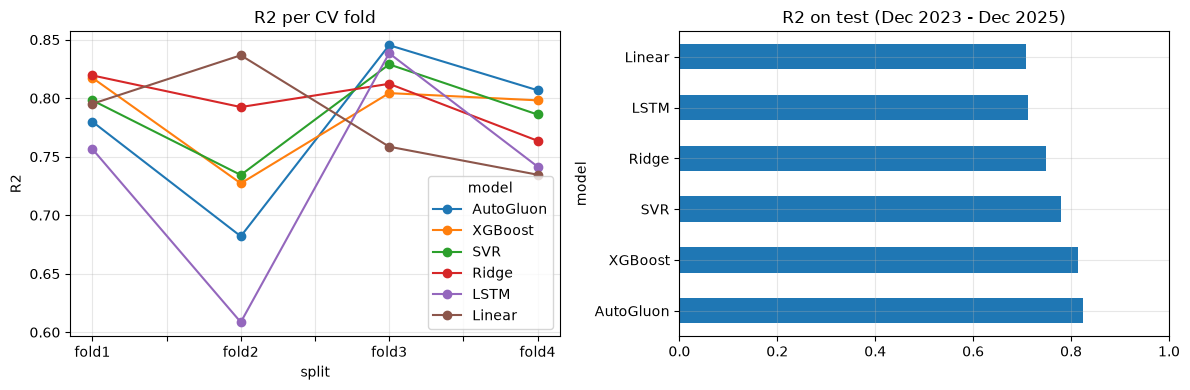

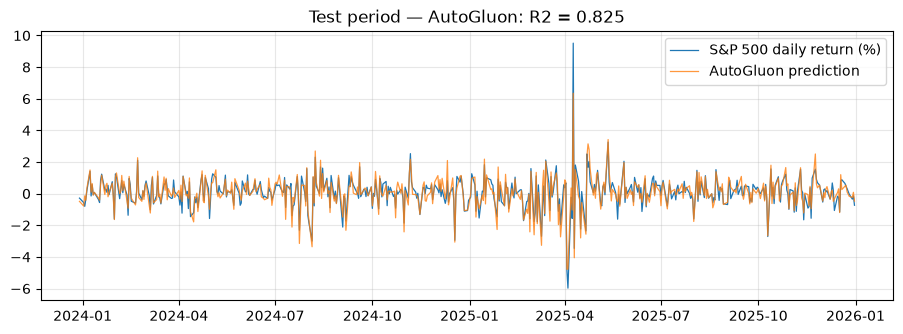

Linear with ranks 1-8 only, R2: {'fold1': 0.721, 'fold2': 0.766, 'fold3': 0.712, 'fold4': 0.723, 'test': 0.739} 
(ถ้าสูงกว่าแบบ 10 อันดับ แปลว่า noise จากหุ้นเข้า/ออกที่อันดับ 9-10 มีผลมากกว่าข้อมูลที่ 2 อันดับนั้นเพิ่มให้)


In [15]:
# ===== 11. Results =====
SPLITS = ['fold1', 'fold2', 'fold3', 'fold4', 'test']
res = pd.DataFrame(results)
tbl = res.pivot(index='model', columns='split', values='R2')[SPLITS]
tbl['cv_mean'] = tbl[SPLITS[:4]].mean(axis=1)
tbl = tbl.sort_values('test', ascending=False)
print('R2'); display(tbl.round(3))
print('RMSE (index points)'); display(res.pivot(index='model', columns='split', values='RMSE')[SPLITS].round(1))
print('all metrics on test (sorted by R2)')
display(res[res.split == 'test'].set_index('model')[METRIC_COLS].sort_values('R2', ascending=False).round(3))
print('all metrics, mean over 4 CV folds')
display(res[res.split != 'test'].groupby('model')[METRIC_COLS].mean().sort_values('R2', ascending=False).round(3))
_lv = df['target_level'].to_numpy(); _iv = TEST['val']
print('MAE/MSE/RMSE = error ของระดับดัชนี (จุด, จุด², จุด), MAPE_% = % ของระดับจริง — baseline ทำนายว่าดัชนีไม่เปลี่ยนจากเมื่อวาน:',
      f'MAE {np.mean(np.abs(_lv[_iv] - _lv[_iv - 1])):.1f} จุด, RMSE {np.sqrt(np.mean((_lv[_iv] - _lv[_iv - 1]) ** 2)):.1f} จุด, MAPE {np.mean(np.abs(y_all[_iv])):.3f} %')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tbl[SPLITS[:4]].T.plot(ax=axes[0], marker='o'); axes[0].set_title('R2 per CV fold'); axes[0].set_ylabel('R2')
tbl['test'].plot.barh(ax=axes[1]); axes[1].set_title('R2 on test (Dec 2023 - Dec 2025)'); axes[1].set_xlim(0, 1)
plt.tight_layout(); plt.show()

best_name = tbl.index[0]
r2_best = float(tbl.loc[best_name, 'test'])
p = preds[(best_name, 'test')]
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df.index[TEST['val']], y_all[TEST['val']], lw=0.9, label='S&P 500 daily return (%)')
ax.plot(df.index[TEST['val']], p, lw=0.9, alpha=0.8, label=f'{best_name} prediction')
ax.set_title(f'Test period — {best_name}: R2 = {r2_best:.3f}'); ax.legend()
plt.show()

# robustness: อันดับ 9-10 เป็น boundary ที่หุ้นเข้า/ออกบ่อย (return ถูก impute) -> เทียบ Linear ที่ใช้เฉพาะอันดับ 1-8
rob = {}
for s in FOLDS + [TEST]:
    m8 = Tabular(LinearRegression()).fit(X_all[RET_COLS[:8]], y_all, s['train'])
    rob[s['name']] = metrics(y_all[s['val']], m8.predict_rows(X_all[RET_COLS[:8]], s['val']))['R2']
print('Linear with ranks 1-8 only, R2:', {k: round(v, 3) for k, v in rob.items()},
      '\n(ถ้าสูงกว่าแบบ 10 อันดับ แปลว่า noise จากหุ้นเข้า/ออกที่อันดับ 9-10 มีผลมากกว่าข้อมูลที่ 2 อันดับนั้นเพิ่มให้)')

In [16]:
# ===== 11b. ความต่างระหว่างโมเดลบน test มีนัยสำคัญไหม? (moving-block bootstrap + Diebold-Mariano) =====
# test มี 503 วันเดียว -> ต้องดูช่วงความเชื่อมั่นของ R2 และของ "ความต่างจาก Linear" ไม่ใช่แค่ตัวเลขจุดเดียว
rng = np.random.default_rng(SEED)
yt = y_all[TEST['val']]
P_test = {name: np.asarray(preds[(name, 'test')], dtype=float) for name in final_models}
n, block, n_boot = len(yt), 21, 2000                      # block 21 วัน (~1 เดือน) รักษา autocorrelation/volatility clustering
starts = rng.integers(0, n - block + 1, size=(n_boot, int(np.ceil(n / block))))
boot_idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(n_boot, -1)[:, :n]
def r2_rows(pred_):
    yb, pb = yt[boot_idx], pred_[boot_idx]
    return 1 - ((yb - pb) ** 2).sum(1) / ((yb - yb.mean(1, keepdims=True)) ** 2).sum(1)
R2b = {name: r2_rows(p_) for name, p_ in P_test.items()}

def dm_test(e_a, e_b, lag=5):
    '''Diebold-Mariano: H0 = squared-error loss ของสองโมเดลเท่ากัน; ค่าบวก = โมเดล b ดีกว่า a'''
    d = e_a ** 2 - e_b ** 2
    m_ = d.mean(); n_ = len(d)
    lrv = d.var(ddof=0) + 2 * sum((1 - h / (lag + 1)) * np.mean((d[h:] - m_) * (d[:-h] - m_)) for h in range(1, lag + 1))
    stat = m_ / np.sqrt(lrv / n_)
    from scipy.stats import norm
    return float(stat), float(2 * (1 - norm.cdf(abs(stat))))

sig_rows = []
for name in final_models:
    lo, hi = np.percentile(R2b[name], [2.5, 97.5])
    row = {'model': name, 'R2 test': float(r2_score(yt, P_test[name])), 'R2 95% CI': f'[{lo:.3f}, {hi:.3f}]'}
    if name != 'Linear':
        dlo, dhi = np.percentile(R2b[name] - R2b['Linear'], [2.5, 97.5])
        stat, pval = dm_test(yt - P_test['Linear'], yt - P_test[name])
        row.update({'dR2 vs Linear 95% CI': f'[{dlo:+.3f}, {dhi:+.3f}]', 'DM stat': stat, 'DM p-value': pval})
    sig_rows.append(row)
significance = pd.DataFrame(sig_rows).set_index('model').sort_values('R2 test', ascending=False)
display(significance.round(3))
print('อ่านผล: CI ของ dR2 ที่ไม่คร่อม 0 และ DM p < 0.05 = ดีกว่า Linear อย่างมีนัยสำคัญบน test นี้ (block bootstrap 2,000 รอบ, block 21 วัน; DM ใช้ Newey-West lag 5)')

,R2 test,R2 95% CI,dR2 vs Linear 95% CI,DM stat,DM p-value
model,,,,,
AutoGluon,0.825,"[0.741, 0.867]","[+0.047, +0.250]",5.488,0.000
XGBoost,0.813,"[0.706, 0.871]","[+0.050, +0.217]",4.853,0.000
SVR,0.780,"[0.691, 0.822]","[-0.000, +0.199]",2.037,0.042
Ridge,0.748,"[0.565, 0.846]","[+0.028, +0.066]",5.604,0.000
LSTM,0.712,"[0.663, 0.755]","[-0.103, +0.176]",0.059,0.953
Linear,0.707,"[0.502, 0.817]",NaN,NaN,NaN


อ่านผล: CI ของ dR2 ที่ไม่คร่อม 0 และ DM p < 0.05 = ดีกว่า Linear อย่างมีนัยสำคัญบน test นี้ (block bootstrap 2,000 รอบ, block 21 วัน; DM ใช้ Newey-West lag 5)


## 12. Feature importance — อันดับไหนสำคัญ

สามมุมมองที่ควรสอดคล้องกัน:
1. **Permutation importance บน test** (model-agnostic): R² ลดลงเท่าไรเมื่อสุ่มสลับ return ของอันดับ k — ใช้ได้กับทุกโมเดลรวม LSTM/AutoGluon
2. **SHAP** ของ XGBoost: ทิศทางและขนาดผลต่อการทำนายรายวัน + dependence plot ดูว่าความสัมพันธ์เป็นเส้นตรงไหม
3. **Coefficient ของ Linear** ราย fold: sensitivity ต่ออันดับและความเสถียรตามเวลา

หมายเหตุ: importance ที่วัดจาก gain ภายใน XGBoost อย่างเดียวไม่พอ เพราะ feature ที่ correlate กันสูงจะถูกเลือกตัวใดตัวหนึ่งมาแบก importance แบบสุ่ม

> **วิธีอ่านผลที่จะเห็น:** importance และ coefficient จะ *ไม่* เรียงตามอันดับ market cap (อันดับ 7–10 มักได้ค่าสูงกว่าอันดับ 1–5) — ไม่ใช่เพราะอันดับ 10 มีน้ำหนักในดัชนีมากกว่าอันดับ 1 แต่เพราะ (ก) อันดับ 1–5 เป็นกลุ่มเทคขนาดใหญ่ที่ correlate กันสูง จึง *แชร์* เครดิตกันใน multiple regression และ (ข) หุ้นที่อันดับ 7–10 (การเงิน สุขภาพ พลังงาน conglomerate) ขยับคล้ายหุ้นอีก 490 ตัวมากกว่า จึงเป็น proxy ของ *ส่วนที่เหลือของดัชนี* ซึ่งไม่ได้อยู่ใน feature ของเรา — section 12d แสดงหลักฐานเรื่องนี้ (marginal corr vs partial coef, correlation matrix, และเช็คว่าไม่ได้เกิดจากการ impute)

Linear     base test R2 = 0.707


Ridge      base test R2 = 0.748


XGBoost    base test R2 = 0.813


SVR        base test R2 = 0.780


LSTM       base test R2 = 0.712


AutoGluon  base test R2 = 0.825


,Linear,Ridge,XGBoost,SVR,LSTM,AutoGluon
rank 1,0.0140,0.0178,0.0439,0.0770,0.0176,0.0318
rank 2,-0.0065,0.0001,0.0099,0.0309,0.0053,0.0243
rank 3,-0.0139,-0.0018,0.0088,0.0287,0.0091,0.0256
rank 4,-0.0221,-0.0174,-0.0090,0.0132,0.0085,0.0189
rank 5,-0.0321,-0.0270,-0.0251,-0.0031,0.0032,0.0017
rank 6,-0.0251,-0.0223,-0.0062,-0.0012,-0.0022,-0.0032
rank 7,-0.0124,-0.0031,0.0105,0.0223,0.0228,0.0370
rank 8,0.0202,0.0251,0.0345,0.0600,0.0504,0.0518
rank 9,0.0686,0.0665,0.0388,0.0560,0.0786,0.0578
rank 10,0.0557,0.0473,0.0275,0.0631,0.0458,0.0537


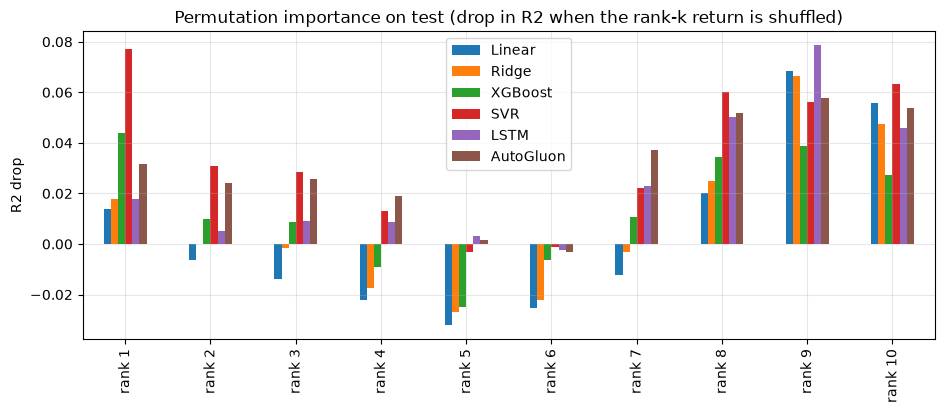

ลำดับอิทธิพลต่อดัชนี แยกตามโมเดล (1 = อันดับที่โมเดลนั้นพึ่งพามากที่สุด; consensus = ค่าเฉลี่ยของลำดับข้ามโมเดล)


,Linear,Ridge,XGBoost,SVR,LSTM,AutoGluon,consensus
rank 9,1,1,2,4,1,1,1.7
rank 10,2,2,4,2,3,2,2.5
rank 8,3,3,3,3,2,3,2.8
rank 1,4,4,1,1,5,5,3.3
rank 7,6,7,5,7,4,4,5.5
rank 2,5,5,6,5,8,7,6.0
rank 3,7,6,7,6,6,6,6.3
rank 4,8,8,9,8,7,8,8.0
rank 6,9,9,8,9,10,10,9.2
rank 5,10,10,10,10,9,9,9.7


สัดส่วน importance ของแต่ละอันดับต่อ importance รวมของโมเดล (%, นับเฉพาะค่าบวก)


,Linear,Ridge,XGBoost,SVR,LSTM,AutoGluon
rank 1,8.8,11.3,25.2,21.9,7.3,10.5
rank 2,0.0,0.0,5.7,8.8,2.2,8.0
rank 3,0.0,0.0,5.1,8.2,3.8,8.5
rank 4,0.0,0.0,0.0,3.8,3.5,6.2
rank 5,0.0,0.0,0.0,0.0,1.3,0.5
rank 6,0.0,0.0,0.0,0.0,0.0,0.0
rank 7,0.0,0.0,6.1,6.4,9.4,12.2
rank 8,12.7,16.0,19.8,17.1,20.9,17.1
rank 9,43.3,42.4,22.3,15.9,32.6,19.1
rank 10,35.1,30.2,15.8,18.0,19.0,17.7


หมายเหตุ: ค่าติดลบ/ศูนย์ = สลับ feature นั้นแล้ว R2 บน test ไม่ลด (หรือดีขึ้น) เพราะ feature ที่ correlate กันแทนกันได้ และ coefficient ที่ fit จาก 2016-23 ใช้กับ 2024-25 ไม่ได้ — ดูคำอธิบายใน 12d


In [17]:
# ===== 12a. Permutation importance on test =====
def perm_importance(predictor, idx, n_repeats=10, seed=SEED):
    rng = np.random.default_rng(seed)
    y = y_all[idx]
    base = r2_score(y, predictor.predict_rows(X_all, idx))
    out = {}
    for c in RET_COLS:
        drop = []
        for _ in range(n_repeats):
            Xp = X_all.copy()
            Xp.iloc[idx, Xp.columns.get_loc(c)] = rng.permutation(Xp[c].to_numpy()[idx])
            drop.append(base - r2_score(y, predictor.predict_rows(Xp, idx)))
        out[c] = float(np.mean(drop))
    return pd.Series(out), base

imp = {}
for name, pr in final_models.items():
    s, base = perm_importance(pr, TEST['val'], n_repeats=5 if name == 'AutoGluon' else 10)
    imp[name] = s
    print(f'{name:10s} base test R2 = {base:.3f}')
imp = pd.DataFrame(imp)
imp.index = [f'rank {k}' for k in range(1, 11)]
display(imp.round(4))

ax = imp.plot.bar(figsize=(11, 4))
ax.set_title('Permutation importance on test (drop in R2 when the rank-k return is shuffled)')
ax.set_ylabel('R2 drop'); plt.show()

# ตารางสรุป: อันดับไหนส่งอิทธิพลต่อดัชนี แยกตามโมเดล (จาก permutation importance บน test)
imp_order = imp.rank(ascending=False).astype(int)                                  # 1 = สำคัญที่สุดสำหรับโมเดลนั้น
imp_order['consensus'] = imp_order.mean(axis=1).round(1)                            # ค่าเฉลี่ยของลำดับข้ามโมเดล (น้อย = สำคัญ)
imp_share = imp.clip(lower=0); imp_share = (imp_share / imp_share.sum() * 100).round(1)   # % ของ importance รวมของโมเดลนั้น (นับเฉพาะค่าบวก)
print('ลำดับอิทธิพลต่อดัชนี แยกตามโมเดล (1 = อันดับที่โมเดลนั้นพึ่งพามากที่สุด; consensus = ค่าเฉลี่ยของลำดับข้ามโมเดล)')
display(imp_order.sort_values('consensus'))
print('สัดส่วน importance ของแต่ละอันดับต่อ importance รวมของโมเดล (%, นับเฉพาะค่าบวก)')
display(imp_share)
print('หมายเหตุ: ค่าติดลบ/ศูนย์ = สลับ feature นั้นแล้ว R2 บน test ไม่ลด (หรือดีขึ้น) เพราะ feature ที่ correlate กันแทนกันได้ และ coefficient ที่ fit จาก 2016-23 ใช้กับ 2024-25 ไม่ได้ — ดูคำอธิบายใน 12d')

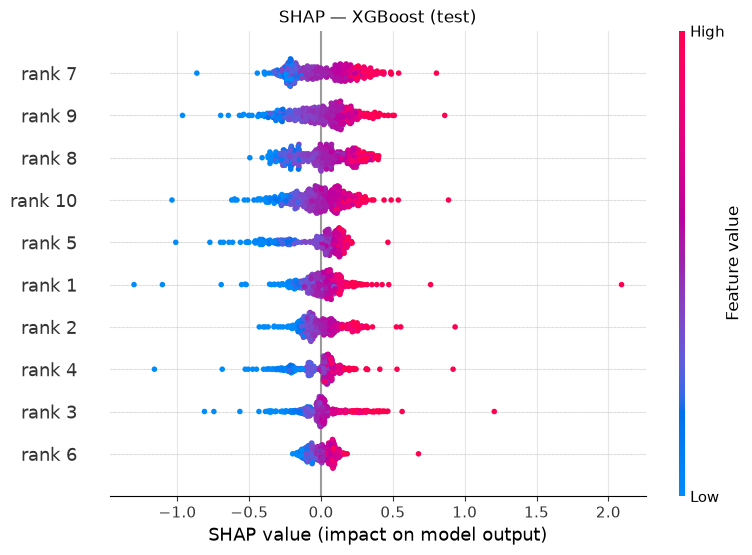

,rank 7,rank 9,rank 8,rank 10,rank 5,rank 1,rank 2,rank 4,rank 3,rank 6
mean |SHAP|,0.1849,0.1711,0.1658,0.1469,0.1453,0.1074,0.1072,0.1053,0.0962,0.0722


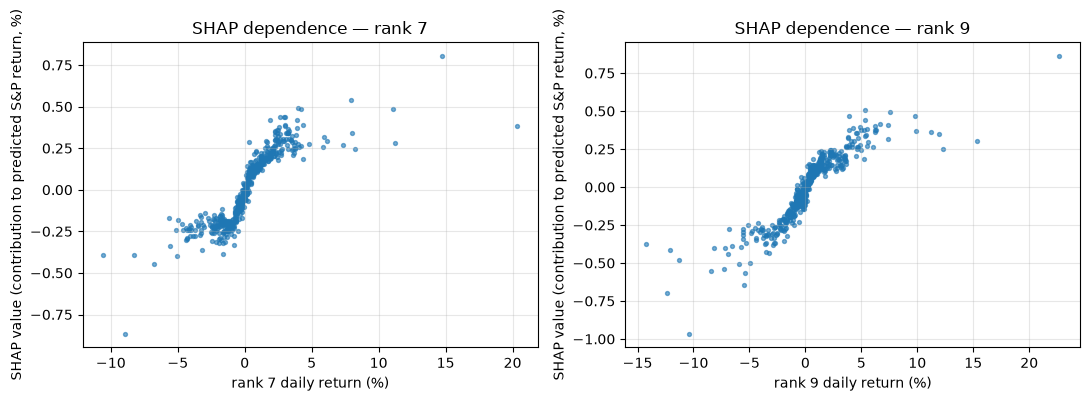

rank,1,2,3,4,5,6,7,8,9,10
slope |r|<2%,0.070,0.086,0.044,0.088,0.113,0.060,0.148,0.144,0.122,0.126
slope |r|>4%,0.117,0.058,0.047,0.074,0.055,0.028,0.045,0.041,0.050,0.056
n days |r|>4%,18.000,24.000,54.000,20.000,19.000,28.000,39.000,49.000,72.000,36.000
ratio tail/center,1.663,0.672,1.086,0.839,0.486,0.476,0.307,0.284,0.411,0.445


slope = SHAP (% point ของดัชนี) ต่อ return 1% ของอันดับนั้น — ratio < 1 = แบนที่ปลาย (non-linear)


In [18]:
# ===== 12b. SHAP (XGBoost, test) =====
try:
    import shap
    names = [f'rank {k}' for k in range(1, 11)]
    X_test = X_all.iloc[TEST['val']].to_numpy()
    sv = shap.TreeExplainer(final_models['XGBoost'].model).shap_values(X_test)
    shap.summary_plot(sv, X_test, feature_names=names, show=False)
    plt.title('SHAP — XGBoost (test)'); plt.show()
    shap_mean = pd.Series(np.abs(sv).mean(0), index=names, name='mean |SHAP|').sort_values(ascending=False)
    display(shap_mean.round(4).to_frame().T)

    # dependence: ผลต่อการทำนาย (แกน y) เทียบกับ return ของอันดับนั้น (แกน x) — ถ้าเป็นเส้นตรง = linear, ถ้าแบนที่ปลาย = ผลของการขยับใหญ่ต่อดัชนีน้อยลง
    top2 = [names.index(n) for n in shap_mean.index[:2]]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, k in zip(axes, top2):
        ax.scatter(X_test[:, k], sv[:, k], s=8, alpha=0.6)
        ax.set_xlabel(f'{names[k]} daily return (%)'); ax.set_ylabel('SHAP value (contribution to predicted S&P return, %)')
        ax.set_title(f'SHAP dependence — {names[k]}')
    plt.tight_layout(); plt.show()

    # ความชันของ SHAP ต่อ return ในช่วงกลาง (|r|<2%) เทียบช่วงปลาย (|r|>4%): ถ้าปลายต่ำกว่ามาก = การขยับใหญ่ส่งผลต่อดัชนีน้อยกว่าสัดส่วนเชิงเส้น
    sl_rows = []
    for k in range(10):
        r_k, s_k = X_test[:, k], sv[:, k]
        c_ = np.abs(r_k) < 2; t_ = np.abs(r_k) > 4
        sl_rows.append({'rank': k + 1, 'slope |r|<2%': np.polyfit(r_k[c_], s_k[c_], 1)[0],
                        'slope |r|>4%': np.polyfit(r_k[t_], s_k[t_], 1)[0] if t_.sum() > 5 else np.nan, 'n days |r|>4%': int(t_.sum())})
    shap_slopes = pd.DataFrame(sl_rows).set_index('rank')
    shap_slopes['ratio tail/center'] = shap_slopes['slope |r|>4%'] / shap_slopes['slope |r|<2%']
    display(shap_slopes.round(3).T)
    print('slope = SHAP (% point ของดัชนี) ต่อ return 1% ของอันดับนั้น — ratio < 1 = แบนที่ปลาย (non-linear)')
except Exception as e:
    print('SHAP skipped:', e)

In [19]:
# ===== 12c. Linear coefficient ราย fold (fit บน train ของ split นั้น) =====
coef_tbl = {}
for s in FOLDS + [TEST]:
    m = Tabular(LinearRegression()).fit(X_all, y_all, s['train'])
    coef_tbl[s['name']] = pd.Series(m.model.coef_, index=RET_COLS)
coef_tbl = pd.DataFrame(coef_tbl)
coef_tbl.loc['sum'] = coef_tbl.sum()
display(coef_tbl.round(3))

,fold1,fold2,fold3,fold4,test
r_1,0.060,0.034,0.055,0.082,0.117
r_2,-0.049,0.094,0.026,0.051,0.054
r_3,0.115,0.062,0.082,0.061,0.048
r_4,0.096,0.045,0.063,0.063,0.049
r_5,0.027,0.047,0.071,0.062,0.066
r_6,0.078,0.064,0.064,0.037,0.037
r_7,0.120,0.075,0.083,0.088,0.077
r_8,0.093,0.112,0.108,0.085,0.082
r_9,0.126,0.146,0.181,0.138,0.119
r_10,0.154,0.126,0.176,0.172,0.144


,corr_with_SP (marginal),OLS coef (partial),corr_with_other9,perm_importance_Linear,perm_importance_XGBoost
rank 1,0.773,0.117,0.794,0.014,0.044
rank 2,0.738,0.054,0.785,-0.006,0.010
rank 3,0.736,0.048,0.792,-0.014,0.009
rank 4,0.750,0.049,0.811,-0.022,-0.009
rank 5,0.709,0.066,0.744,-0.032,-0.025
rank 6,0.572,0.037,0.577,-0.025,-0.006
rank 7,0.589,0.077,0.535,-0.012,0.011
rank 8,0.581,0.082,0.537,0.020,0.035
rank 9,0.628,0.119,0.572,0.069,0.039
rank 10,0.619,0.144,0.532,0.056,0.027


VIF (train): {'rank 1': 3.08, 'rank 2': 2.97, 'rank 3': 3.41, 'rank 4': 4.18, 'rank 5': 2.66, 'rank 6': 1.54, 'rank 7': 1.46, 'rank 8': 1.43, 'rank 9': 1.49, 'rank 10': 1.42}  -> 1-5 = collinearity ปานกลาง, >10 = รุนแรง; OLS ยังใช้ได้ แต่ coefficient แต่ละตัวมีความไม่แน่นอน (ดู CI ใน section 6) และแชร์เครดิตกัน


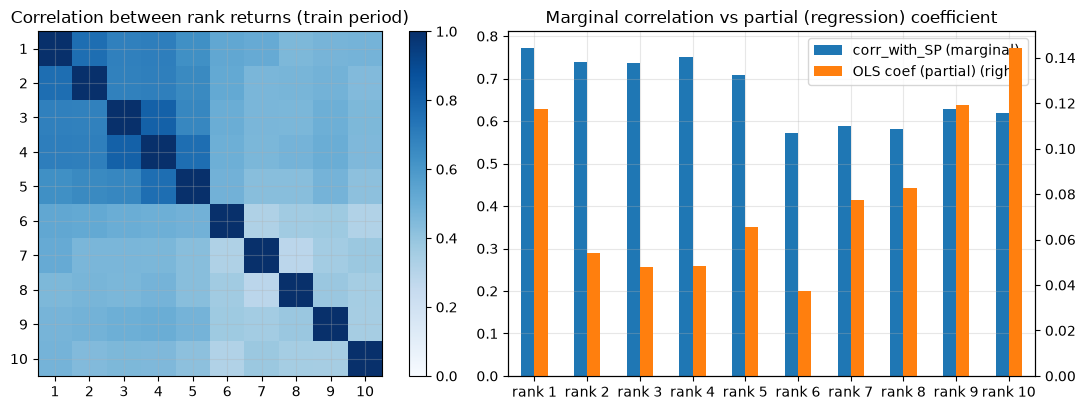

OLS coefficients excluding imputed days: {'r_1': np.float64(0.105), 'r_2': np.float64(0.068), 'r_3': np.float64(0.042), 'r_4': np.float64(0.061), 'r_5': np.float64(0.057), 'r_6': np.float64(0.037), 'r_7': np.float64(0.08), 'r_8': np.float64(0.084), 'r_9': np.float64(0.116), 'r_10': np.float64(0.139)} | test R2 0.723  (ถ้าใกล้เคียงตารางด้านบน = ไม่ใช่ผลของการ impute)


In [20]:
# ===== 12d. ทำไม importance/coefficient ไปกระจุกที่อันดับ 7-10? ดูโครงสร้าง correlation =====
# marginal = corr ของอันดับ k กับ S&P ตรงๆ ; partial = coefficient ใน multiple regression (คุมอันดับอื่น) ; corr_others = corr กับค่าเฉลี่ยของอีก 9 อันดับ
idx_tr = valid(TEST['train'])
Xtr_np, ytr_np = X_all.to_numpy()[idx_tr], y_all[idx_tr]
struct = pd.DataFrame({
    'corr_with_SP (marginal)': [np.corrcoef(Xtr_np[:, k], ytr_np)[0, 1] for k in range(10)],
    'OLS coef (partial)': coef_tbl['test'].iloc[:10].to_numpy(),
    'corr_with_other9': [np.corrcoef(Xtr_np[:, k], np.delete(Xtr_np, k, axis=1).mean(1))[0, 1] for k in range(10)],
    'perm_importance_Linear': imp['Linear'].to_numpy(),
    'perm_importance_XGBoost': imp['XGBoost'].to_numpy(),
}, index=[f'rank {k}' for k in range(1, 11)])
display(struct.round(3))
from statsmodels.stats.outliers_influence import variance_inflation_factor
_Xc = sm.add_constant(Xtr_np)
vif = pd.Series([variance_inflation_factor(_Xc, k) for k in range(1, 11)], index=[f'rank {k}' for k in range(1, 11)], name='VIF')
print('VIF (train):', vif.round(2).to_dict(), ' -> 1-5 = collinearity ปานกลาง, >10 = รุนแรง; OLS ยังใช้ได้ แต่ coefficient แต่ละตัวมีความไม่แน่นอน (ดู CI ใน section 6) และแชร์เครดิตกัน')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
im = axes[0].imshow(np.corrcoef(Xtr_np.T), vmin=0, vmax=1, cmap='Blues')
axes[0].set_xticks(range(10)); axes[0].set_yticks(range(10))
axes[0].set_xticklabels(range(1, 11)); axes[0].set_yticklabels(range(1, 11))
axes[0].set_title('Correlation between rank returns (train period)'); plt.colorbar(im, ax=axes[0], fraction=0.046)
struct[['corr_with_SP (marginal)', 'OLS coef (partial)']].plot.bar(ax=axes[1], secondary_y='OLS coef (partial)', rot=0)
axes[1].set_title('Marginal correlation vs partial (regression) coefficient')
plt.tight_layout(); plt.show()

# เช็คว่าไม่ได้เกิดจากการ impute วันหุ้นเข้า/ออก: fit ใหม่โดยตัดวันที่มี impute ออก
keep = ~(df['n_unmatched'].to_numpy() > 0)
tr_k = idx_tr[keep[idx_tr]]; te_k = TEST['val'][keep[TEST['val']]]
lr_k = LinearRegression().fit(X_all.to_numpy()[tr_k], y_all[tr_k])
print('OLS coefficients excluding imputed days:', dict(zip(RET_COLS, np.round(lr_k.coef_, 3))),
      f'| test R2 {lr_k.score(X_all.to_numpy()[te_k], y_all[te_k]):.3f}  (ถ้าใกล้เคียงตารางด้านบน = ไม่ใช่ผลของการ impute)')

## 13. อิทธิพลเปลี่ยนตามเวลา

Fit linear แยกรายปี (และ rolling 252 วัน) เพื่อดูว่า R² และ sensitivity ของ top 10 เพิ่มขึ้นตามการกระจุกตัวของดัชนีหรือไม่
- `R2_10slots` = R² ของ linear บน 10 อันดับในปีนั้น
- `beta_EW` = ดัชนีขยับกี่ % เมื่อค่าเฉลี่ย (equal-weight) ของ top 10 ขยับ 1%
- `sum_coef` = ผลรวม coefficient ของ 10 อันดับ (sensitivity รวม)

,R2_10slots,corr_EW,beta_EW,beta_EW_rank1to8,sum_coef
year,,,,,
2016,0.765,0.844,0.775,0.661,0.857
2017,0.784,0.799,0.562,0.445,0.739
2018,0.926,0.949,0.747,0.677,0.809
2019,0.843,0.902,0.718,0.641,0.774
2020,0.893,0.927,0.933,0.865,1.014
2021,0.796,0.863,0.620,0.523,0.690
2022,0.924,0.947,0.703,0.661,0.771
2023,0.765,0.849,0.521,0.460,0.581
2024,0.812,0.882,0.531,0.501,0.557


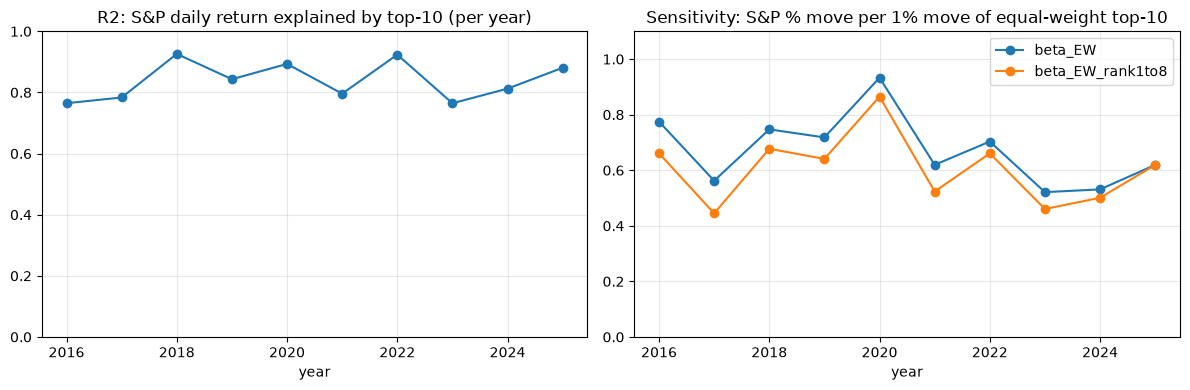

,rank 1,rank 2,rank 3,rank 4,rank 5,rank 6,rank 7,rank 8,rank 9,rank 10
"2016-2019 corr(rank, other 9)",0.77,0.80,0.74,0.78,0.66,0.54,0.58,0.49,0.49,0.50
"2016-2019 corr(rank, S&P)",0.71,0.75,0.70,0.72,0.63,0.57,0.61,0.58,0.58,0.59
"2020-2022 corr(rank, other 9)",0.84,0.80,0.83,0.85,0.81,0.62,0.55,0.56,0.62,0.60
"2020-2022 corr(rank, S&P)",0.82,0.75,0.79,0.80,0.77,0.60,0.61,0.60,0.66,0.68
"2023-2025 corr(rank, other 9)",0.64,0.60,0.64,0.74,0.65,0.55,0.55,0.38,0.49,0.47
"2023-2025 corr(rank, S&P)",0.71,0.62,0.66,0.68,0.59,0.53,0.59,0.46,0.58,0.55


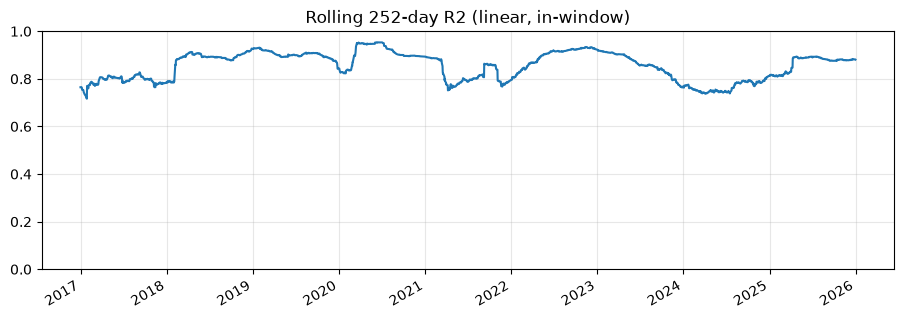

In [21]:
# ===== 13. Influence over time =====
years = df.index.year
rows = []
for yr in sorted(set(years)):
    m = (years == yr) & ~np.isnan(y_all)
    Xy, yy = X_all.to_numpy()[m], y_all[m]
    lr_y = LinearRegression().fit(Xy, yy)
    ew_y = Xy.mean(axis=1)
    rows.append({'year': yr, 'R2_10slots': lr_y.score(Xy, yy), 'corr_EW': np.corrcoef(ew_y, yy)[0, 1],
                 'beta_EW': np.polyfit(ew_y, yy, 1)[0], 'sum_coef': lr_y.coef_.sum(),
                 'beta_EW_rank1to8': np.polyfit(Xy[:, :8].mean(axis=1), yy, 1)[0],
                 **{f'w{k + 1}': c for k, c in enumerate(lr_y.coef_)}})
yearly = pd.DataFrame(rows).set_index('year')
display(yearly[['R2_10slots', 'corr_EW', 'beta_EW', 'beta_EW_rank1to8', 'sum_coef']].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
yearly['R2_10slots'].plot(ax=axes[0], marker='o'); axes[0].set_ylim(0, 1)
axes[0].set_title('R2: S&P daily return explained by top-10 (per year)')
yearly[['beta_EW', 'beta_EW_rank1to8']].plot(ax=axes[1], marker='o'); axes[1].set_ylim(0, 1.1)
axes[1].set_title('Sensitivity: S&P % move per 1% move of equal-weight top-10')
plt.tight_layout(); plt.show()

# correlation ภายในกลุ่ม top 10 แยกช่วงเวลา: corr(rank k, ค่าเฉลี่ยของอีก 9 อันดับ) และ corr(rank k, S&P) — ใช้ประกอบข้อสรุปเรื่อง regime
per = {}
for lo, hi in [(2016, 2019), (2020, 2022), (2023, 2025)]:
    m_ = (years >= lo) & (years <= hi) & ~np.isnan(y_all)
    Xm = X_all.to_numpy()[m_]
    per[f'{lo}-{hi} corr(rank, other 9)'] = [np.corrcoef(Xm[:, k], np.delete(Xm, k, axis=1).mean(1))[0, 1] for k in range(10)]
    per[f'{lo}-{hi} corr(rank, S&P)'] = [np.corrcoef(Xm[:, k], y_all[m_])[0, 1] for k in range(10)]
corr_period = pd.DataFrame(per, index=[f'rank {k}' for k in range(1, 11)]).T
display(corr_period.round(2))

# rolling 252-day R2 (in-window fit)
win = 252
roll = {}
for end in range(win, len(df) + 1):
    sl = valid(np.arange(end - win, end))
    Xw, yw = X_all.to_numpy()[sl], y_all[sl]
    roll[df.index[end - 1]] = LinearRegression().fit(Xw, yw).score(Xw, yw)
roll = pd.Series(roll)
ax = roll.plot(figsize=(11, 3.5)); ax.set_ylim(0, 1); ax.set_title('Rolling 252-day R2 (linear, in-window)')
plt.show()

## 14. สรุปผลและการตีความ

ตัวเลขด้านล่างมาจากการรัน notebook นี้ (seed 42; LSTM/AutoGluon อาจต่างเล็กน้อยตามเครื่องและ time limit)

### 1. Top 10 อธิบายการเคลื่อนไหวรายวันของ S&P 500 ได้ประมาณ 80%
- **CV (2018–2023, 4 fold):** ทุกโมเดลแบบ tabular ได้ R² เฉลี่ย **0.78–0.80** (Ridge 0.797, XGBoost 0.787, SVR 0.787, Linear 0.781, AutoGluon 0.779) LSTM ต่ำกว่า (0.736)
- **Test (ธ.ค. 2023 – ธ.ค. 2025, ไม่เคยแตะ):** AutoGluon **0.825**, XGBoost **0.813**, SVR 0.780, Ridge 0.748, LSTM 0.712, Linear 0.707
- R² รายปี (in-sample, linear) อยู่ระหว่าง 0.77–0.93 — **สูงสุดในปีวิกฤต** (2018 = 0.93, 2022 = 0.92, 2020 = 0.89) ต่ำสุดในปีที่ตลาดนิ่งและหุ้นแยกทางกัน (2017, 2023 = 0.77)
- ตัวเลขนี้เป็น *ความสัมพันธ์เชิงสถิติ* ซึ่งรวมทั้งน้ำหนักจริงในดัชนี (~35–40%) และการที่หุ้นอีก 490 ตัวขยับไปทางเดียวกับ top 10

### 2. Sensitivity ของดัชนีต่อ top 10 ขึ้นกับ regime ของตลาด และต่ำสุดในปี 2023–24
- `beta_EW` (ดัชนีขยับกี่ % เมื่อค่าเฉลี่ย top 10 ขยับ 1%) **สูงในปีที่ตลาดผันผวน** (2020 = 0.93, 2016/2018/2019 = 0.72–0.78, 2022 = 0.70) และ **ต่ำในปีที่ตลาดนิ่ง** (2017 = 0.56, 2021 = 0.62, 2023 = 0.52, 2024 = 0.53, 2025 = 0.62) — ปี 2023–24 ต่ำที่สุดในรอบ 10 ปี ผลรวม coefficient ให้ภาพเดียวกัน (2020 = 1.01 → 2023–25 = 0.56–0.62) และยังเป็นแบบนี้เมื่อใช้เฉพาะอันดับ 1–8 (`beta_EW_rank1to8`) จึงไม่ใช่ noise จาก boundary
- correlation ระหว่างหุ้น top 10 ด้วยกันเองในช่วง 2023–25 (0.60–0.74 สำหรับอันดับ 1–4) ต่ำกว่าช่วง 2016–22 (0.74–0.85 แยกช่วงย่อย; ตาราง corr_period ใน section 13) → mega-cap tech ขยับด้วยเรื่องของตัวเอง (AI) มากขึ้น ส่วนที่เหลือของตลาดตามน้อยลง — **ดัชนีกระจุกตัวมากขึ้น แต่ "ลากตาม" น้อยลง** อย่างน้อยในช่วงตลาดสงบ; ยังบอกไม่ได้ว่าเป็นเทรนด์ถาวรหรือแค่ regime (ปี 2025 ที่ผันผวนกว่า beta กลับขึ้นมา 0.62)
- ⚠️ coefficient/beta เหล่านี้ *ไม่ใช่* น้ำหนัก market cap (สูงกว่าเพราะรวม co-movement) การแยก mechanical weight ต้องมี market cap

### 3. อันดับไหนสำคัญ — คำตอบขึ้นกับว่าถามอะไร
- Permutation importance บน test (ทุกโมเดลรวม AutoGluon) และ coefficient ของ linear ไปกระจุกที่ **อันดับ 7–10** (OLS coef r_10 = 0.14, r_9 = 0.12 vs r_1 = 0.12, r_3–r_6 = 0.04–0.07) และ SHAP ของ XGBoost ก็ให้อันดับ 7, 9, 8, 10 สูงสุด
- section 12d แสดงว่านี่คือผลของ (ก) อันดับ 1–5 correlate กันสูง (0.74–0.81 กับค่าเฉลี่ยของกลุ่ม) จึงแชร์เครดิตกัน — marginal correlation กับ S&P ของอันดับ 1–4 สูงที่สุด (0.74–0.77) แต่ partial coefficient ต่ำ — และ (ข) อันดับ 7–10 (corr กับกลุ่มแค่ 0.53–0.57) เป็น proxy ของหุ้นอีก 490 ตัว — ไม่ได้เกิดจากการ impute (ตัดวันที่ impute ออก coefficient แทบไม่เปลี่ยน)
- ดังนั้น "importance ต่ออันดับ" จากโมเดลพวกนี้ตอบว่า *ช่องไหนให้ข้อมูลเกี่ยวกับดัชนีที่ช่องอื่นไม่มี* ไม่ได้ตอบว่า *ช่องไหนขยับดัชนีมากที่สุดเชิงกลไก* (คำตอบหลังต้องใช้ weight × return)

### 4. Linear vs non-linear
- ใน CV ทุกโมเดลใกล้กัน (0.78–0.80) — ความสัมพันธ์โดยพื้นฐานเป็นเชิงเส้น ตามโครงสร้างดัชนี
- บน test AutoGluon/XGBoost/SVR นำ OLS ~0.07–0.12: ส่วนหนึ่งเพราะ coefficient ของ OLS เลื่อนตามเวลา (Ridge ที่ shrink แรง α=1000 ดีกว่า OLS) และ SHAP dependence แสดง non-linearity ที่ชัดเจน: สำหรับอันดับส่วนใหญ่ (โดยเฉพาะ 5–10) ความชันของผลต่อดัชนีในช่วง |return| > 4% ต่ำกว่าช่วง |return| < 2% ราว 2–3 เท่า — **การขยับใหญ่ของหุ้นตัวเดียวมักเป็นเรื่องเฉพาะตัว ตลาดไม่ตาม** tree model จับตรงนี้ได้ linear ทำไม่ได้
- **Fold 2 (COVID)** โมเดลยืดหยุ่นทุกตัวแย่ลงมาก (XGBoost 0.73, SVR 0.73, AutoGluon 0.68, LSTM 0.61) แต่ **Linear ได้ดีที่สุด (0.84)** — วันที่ตลาด ±10% เกินช่วงที่เคยเห็น โมเดลเชิงเส้น extrapolate ได้ tree/kernel/LSTM ทำไม่ได้ → ถ้าเป้าหมายคือความทนทานในวิกฤต Linear/Ridge เหมาะกว่า
- LSTM ≈ Linear ตามคาด: return รายวันแทบไม่มี autocorrelation ประวัติย้อนหลังไม่ช่วย
- AutoGluon (ensemble ของ CatBoost/LightGBM/NN) ดีที่สุดบน test แต่ CV เฉลี่ยไม่ต่างจากโมเดลเดี่ยว — กำไรจาก ensemble มาจากความทนทานต่อ regime 2024–25 ไม่ใช่จากโครงสร้างที่ต่างออกไป
- **นัยสำคัญ (section 11b, block bootstrap 2,000 รอบ + Diebold–Mariano):** AutoGluon และ XGBoost ดีกว่า Linear บน test อย่างมีนัยสำคัญ (ΔR² 95% CI [+0.05, +0.25] และ [+0.05, +0.22], DM p < 0.001); Ridge ดีกว่าเล็กน้อยแต่มีนัย (CI [+0.03, +0.07]); SVR ก้ำกึ่ง (p = 0.04, CI แตะ 0); LSTM ไม่ต่างจาก Linear (p = 0.95) — CI ของ R² แต่ละโมเดลกว้าง (เช่น Linear [0.50, 0.82]) เพราะ test มี 503 วันและมีวันผันผวนสูงเป็นช่วงๆ

### 5. ข้อจำกัด
- คอลัมน์เป็นช่องอันดับ ไม่มี ticker → ตีความได้ระดับ *อันดับ* ไม่ใช่รายบริษัท และการจับคู่ (un-swap) เป็นการอนุมาน — ตรวจสอบแล้วว่าคู่ราคาใกล้กัน (GOOGL/GOOG) ได้ correlation 0.98 และ R² test ดีขึ้นจาก −1.9 (ไม่ un-swap) เป็น 0.71 แต่ยังอาจมีวันที่จับคู่ผิดที่อันดับ 9–10
- ไม่มี market cap → แยกน้ำหนักจริงออกจาก co-movement ไม่ได้
- วันหุ้นเข้า/ออก top 10 (~200 วัน เกือบทั้งหมดที่อันดับ 9–10) ใช้ค่าเฉลี่ยของช่องอื่นแทน และการขยับจริง >20% ที่อันดับ 9–10 ถูกตัดไปด้วย (~1–2 event เช่น AVGO +24% 13/12/2024)
- adj close ถูกปรับย้อนหลังตามปันผล (ผลต่อ return รายวันน้อยมาก)
- test เป็นช่วงเดียว (2024–25) — อันดับของโมเดลบน test ควรอ่านคู่กับ CV
- กฎหุ้นเข้า/ออกที่ boundary (idiosyncratic jump > 20% ที่อันดับ 9–10) ตั้งขึ้นหลังตรวจพบ event ปลอมจากการสลับ TSLA/AVGO ในปี 2024 ซึ่งอยู่ในช่วง test — เป็น data cleaning จากการเทียบกับราคาจริง ไม่ใช่การจูนกับ R² test แต่ section 3b เปิดเผยผลเมื่อใช้เกณฑ์อื่นหรือปิดกฎ (R² test 0.63–0.71) เพื่อให้ผู้อ่านตัดสินเอง

### 6. ส่วนต่อขยายที่คุ้มค่า
- เพิ่ม market cap / index weight รายวัน → contribution จริง = weight × return แล้วเทียบกับ R² และ sensitivity
- เพิ่ม proxy ของอีก 490 ตัว (เช่น equal-weight ETF `RSP` หรือ S&P 500 ex-top-10) เพื่อแยกผลของ top 10 ออกจาก market factor
- ทำแบบ ticker-based เพื่ออธิบายเป็นรายบริษัท


## 15. คำถามที่อาจถูกถาม — และคำตอบจากผลในไฟล์นี้

**Q1. Top 10 อยู่ในดัชนีอยู่แล้ว R² สูงจึงเป็นเรื่องธรรมดาไม่ใช่หรือ?**
ใช่ส่วนหนึ่ง — top 10 มีน้ำหนักในดัชนี ~35–40% (ปี 2024–25) ส่วนนั้นเป็น "กลไก" ที่หลีกเลี่ยงไม่ได้ แต่ R² ~0.8 สูงกว่าน้ำหนักมาก ส่วนต่างคือ *co-movement* ของหุ้นอีก 490 ตัว งานนี้จึงวัด "อิทธิพลเชิงสถิติ" (อธิบายความแปรปรวนได้เท่าไร และ sensitivity เปลี่ยนตามเวลาอย่างไร) และระบุชัดว่าการแยก mechanical weight ต้องมี market cap (section 14 ข้อ 5–6)

**Q2. ทำไมไม่ทำนายอนาคต (t+1)?**
เพราะโจทย์คือ "อิทธิพล" ไม่ใช่การพยากรณ์ และ section 3 (ข้อ 3) แสดงว่าถ้าใช้ return ของ top 10 เมื่อวานทำนายวันนี้ R² ≈ 0 ตามที่ทฤษฎีตลาดมีประสิทธิภาพคาดไว้ — ตัวเลข same-day จึงไม่ใช่ผลของ look-ahead

**Q3. ทำไมไม่ใช้ราคา (level) ที่ normalize แล้ว?**
Section 2: level ไม่ stationary (ADF p สูง) → regression เป็น spurious (placebo "ลำดับวัน" อย่างเดียวได้ R² 0.88, Durbin-Watson 0.14) และ XGBoost บน level ได้ test R² = −4.1 เพราะ extrapolate ไม่ได้ ส่วน return stationary (ADF p ≈ 0) และ DW ≈ 2

**Q4. การ un-swap เชื่อถือได้แค่ไหน ในเมื่อไม่มี ticker?**
ตรวจสอบ 4 ทาง (section 3): (1) คู่หุ้นราคาใกล้กัน (GOOGL/GOOG) ได้ correlation ของ return 0.976; (2) R² test เปลี่ยนจาก −1.9 (ไม่ un-swap) เป็น 0.71; (3) การขยับใหญ่ที่เก็บไว้ตรงกับเหตุการณ์จริงที่ทราบวันที่ (META −19% 26/7/2018, NVDA +24% 25/5/2023, META +20% 2/2/2024, NVDA −17% 27/1/2025 ฯลฯ); (4) section 3b: ขยับพารามิเตอร์ทุกตัว (penalty, cap, threshold, boundary, วิธี impute) ผลระดับรวมแทบไม่เปลี่ยน; rank penalty จำเป็นต่อความถูกต้องรายช่อง (twin corr 0.976 → 0.92 ถ้าเอาออก) และกฎ boundary jump >20% มีผลต่อ R² test เพราะ event ปลอมจากการสลับ TSLA/AVGO เกือบทั้งหมดอยู่ในปี 2024 — เกณฑ์นี้ตั้งจากการตรวจสอบ event กับราคาจริงของหุ้น (data cleaning) ไม่ใช่การจูนกับ R² test และตาราง 3b เปิดเผยผลเมื่อใช้เกณฑ์อื่นหรือปิดกฎ

**Q5. Hyperparameter ถูกเลือกโดยเห็น test ไหม?**
ไม่ — ทุก search ใช้ค่าเฉลี่ย R² ของ 4 val fold เท่านั้น (section 7–9) แล้ว fit ใหม่บน train ทั้งหมด วัด test ครั้งเดียว; LSTM early stopping และ AutoGluon tuning ใช้ส่วนท้ายของ train (อดีต) ไม่ใช่ val/test; scaler fit ต่อ fold

**Q6. ค่า val ของ fold ที่รายงาน optimistic ไหม?**
ใช่เล็กน้อยสำหรับโมเดลที่ search (XGBoost/SVR/LSTM/Ridge) เพราะ config ถูกเลือกจาก fold เหล่านั้น — จึงใช้ test เป็นตัวเลขหลัก และ section 11b ให้ช่วงความเชื่อมั่น

**Q7. AutoGluon 0.825 vs Linear 0.707 ต่างกันจริงหรือแค่โชค?**
Section 11b: block bootstrap 2,000 รอบให้ 95% CI ของ ΔR² และ Diebold–Mariano test (Newey-West) ระบุว่าโมเดลไหนดีกว่า Linear อย่างมีนัยสำคัญบน test — อ่านค่าจากตารางนั้นโดยตรง

**Q8. ทำไม importance ไม่เรียงตาม market cap?**
Section 12d: อันดับ 1–5 correlate กันสูง (VIF และ corr กับกลุ่ม 0.74–0.81) จึงแชร์เครดิต ส่วนอันดับ 7–10 เป็น proxy ของหุ้นอีก 490 ตัว — เช็คแล้วว่าไม่ได้เกิดจากการ impute

**Q9. Linear ชนะทุกโมเดลใน fold COVID ได้อย่างไร?**
วันที่ตลาด ±10% เกินช่วงที่ train เคยเห็น tree/kernel/LSTM ให้ค่าทำนายแบน (extrapolate ไม่ได้) แต่ linear extrapolate ได้ตามโครงสร้างดัชนีที่เป็นผลรวมถ่วงน้ำหนัก

**Q10. LSTM ทำไมแย่กว่า Linear?**
Return รายวันแทบไม่มี autocorrelation (corr ของ EW top 10 เมื่อวานกับดัชนีวันนี้ ≈ −0.13) ประวัติย้อนหลังจึงไม่เพิ่มข้อมูล แต่เพิ่มพารามิเตอร์และความแปรปรวน; early stopping หยุดเร็ว (~13 epoch)

**Q11. MAPE ทำไมคำนวณบนระดับดัชนี?**
สูตร MAPE หารด้วยค่าจริง ซึ่ง return รายวันใกล้ 0 บ่อยมาก (12% ของวัน |return| < 0.1%) ทำให้ได้ตัวเลขหลายร้อย % ที่ไม่สื่ออะไร จึงแปลง return ที่ทำนายเป็นระดับดัชนีก่อนตามธรรมเนียมงานทำนายราคา (section 5, 11) — MAE/MSE/RMSE ก็รายงานเป็นจุดดัชนีบนระดับเดียวกัน (MAE จุด ≈ MAE ของ return % × ระดับดัชนี / 100)

**Q12. Split 4 fold × 365 วันซื้อขาย ทำไมไม่แบ่งตามปี?**
เป็นการออกแบบตามแผนงาน (train 80% / test 20%, expanding window) 365 วันซื้อขาย ≈ 1 ปี 5 เดือน ผลรายปีมีใน section 13 ให้ดูประกอบ

**Q13. ข้อมูล adj close มีผลไหม?**
Adj close ปรับปันผลย้อนหลัง ทำให้ *ระดับ* ไม่ตรงราคาซื้อขายจริง แต่ return รายวันต่างจาก close ปกติเฉพาะวัน ex-dividend (~0.5% ต่อไตรมาสสำหรับหุ้นปันผล) ผลต่อการวิเคราะห์ return รายวันน้อยมาก; target (S&P 500) เป็น close จริง ตรวจสอบกับค่าที่ทราบแล้ว (เช่น 23/3/2020 = 2,237.40)

**Q14. ผลนี้ generalize ไปอนาคตได้ไหม?**
Test เป็นช่วงเดียว (2024–25) และ sensitivity ขึ้นกับ regime (section 13) จึงควรรายงานเป็น "ช่วง 2016–2025" และ re-fit เมื่อมีข้อมูลใหม่ ไม่ควรอ้างเป็นค่าคงที่

In [22]:
# ===== 16. Export bundle สำหรับ dashboard (streamlit run dashboard.py) =====
# ผลลัพธ์ทั้งหมดเก็บเป็น dashboard_data.pkl ไฟล์เดียว ไม่สรุปเป็น csv
import pickle, datetime, platform

pred_rows = []
for (name, split), p in preds.items():
    s = next(x for x in FOLDS + [TEST] if x['name'] == split)
    pred_rows.append(pd.DataFrame({'date': df.index[s['val']], 'model': name, 'split': split,
                                   'y_true': y_all[s['val']], 'y_pred': np.asarray(p, dtype=float)}))
predictions = pd.concat(pred_rows, ignore_index=True)

level_demo = {'placebo_time_index_train_R2': float(r2_score(y_lvl[tr], lr.predict(t_idx[tr])))}
for k, v in level_pred.items():
    level_demo[f'{k}_level_train_R2'] = float(r2_score(y_lvl[tr], v[tr]))
    level_demo[f'{k}_level_test_R2'] = float(r2_score(y_lvl[te], v[te]))
level_series = pd.DataFrame({'actual': y_lvl, **{k: v for k, v in level_pred.items()}}, index=raw.index)

lr_naive = LinearRegression().fit(naive[tr_i], y_chk[tr_i]); lr_unsw = LinearRegression().fit(df[RET_COLS].to_numpy()[tr_i], y_chk[tr_i])
unswap_check = {'naive_train_R2': float(lr_naive.score(naive[tr_i], y_chk[tr_i])), 'naive_test_R2': float(lr_naive.score(naive[te_i], y_chk[te_i])),
                'unswapped_train_R2': float(lr_unsw.score(df[RET_COLS].to_numpy()[tr_i], y_chk[tr_i])),
                'unswapped_test_R2': float(lr_unsw.score(df[RET_COLS].to_numpy()[te_i], y_chk[te_i])),
                'twin_pairs': int(mask.sum()), 'twin_corr': float(np.corrcoef(a_, b_)[0, 1]),
                'corr_EW_SP': float(ew.corr(df[TARGET])), 'corr_proxy_SP': float(mkt_proxy.corr(df[TARGET]))}
unswap_scatter = pd.DataFrame({'ew_before': naive.mean(axis=1), 'ew_after': ew.to_numpy(), 'sp': y_chk}, index=df.index)

bundle = {
    'meta': {'run_at': datetime.datetime.now().isoformat(timespec='seconds'), 'seed': SEED, 'python': platform.python_version(),
             'pandas': pd.__version__, 'n_rows': int(len(df)), 'period': f'{df.index[0].date()} -> {df.index[-1].date()}',
             'swap_days': int(df.swapped.sum()), 'entry_exit_slots': int(df.n_unmatched.sum()),
             'entry_exit_days': int((df.n_unmatched > 0).sum()), 'run_autogluon': bool(RUN_AUTOGLUON), 'ag_time_limit': AG_TIME_LIMIT,
             'models': list(final_models.keys())},
    'splits': pd.DataFrame(split_tbl),
    'results': res,
    'predictions': predictions,
    'importance': imp, 'importance_order': imp_order, 'importance_share': imp_share,
    'shap_mean': globals().get('shap_mean'),
    'coef_tbl': coef_tbl,
    'struct': struct,
    'ols_summary': str(ols.summary(xname=['const'] + RET_COLS)),
    'yearly': yearly,
    'rolling_r2': roll,
    'returns': df,
    'diag': diag,
    'exit_by_rank': exit_by_rank,
    'mkt_proxy': mkt_proxy,
    'search': {'xgboost': xgb_search, 'svr': svr_search, 'lstm': lstm_search, 'ridge': ridge_search},
    'best_params': {'xgboost': best_xgb, 'svr': best_svr, 'lstm': {'L': best_L, 'hidden': best_h}, 'ridge': {'alpha': best_alpha}},
    'ag_leaderboard': ag.predictor.leaderboard() if 'ag' in globals() else None,
    'level_demo': level_demo, 'level_series': level_series,
    'unswap_check': unswap_check, 'unswap_scatter': unswap_scatter,
    'rank8_check': rob,
    'sensitivity': sensitivity, 'significance': significance, 'corr_period': corr_period,
    'shap_slopes': globals().get('shap_slopes'), 'vif': vif,
    'adf': {'level_p': adf_level_p, 'return_p': adf_return_p}, 'nextday_r2': nextday_r2,
}
with open('dashboard_data.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print('saved dashboard_data.pkl  ->  เปิด dashboard ด้วย:  streamlit run dashboard.py')


saved dashboard_data.pkl  ->  เปิด dashboard ด้วย:  streamlit run dashboard.py
